# **Introdução**

## Contexto

Este é um conjunto de dados público brasileiro de comércio eletrónico relativo a encomendas efetuadas na Olist Store. O conjunto de dados contém informações sobre 100 mil encomendas, de 2016 a 2018, efetuadas em várias plataformas de comércio eletrónico no Brasil. As suas características permitem analisar uma encomenda sob várias perspetivas: desde o estado da encomenda, preço, pagamento e desempenho do envio até à localização do cliente, atributos do produto e, por fim, comentários escritos pelos clientes.

Este conjunto de dados foi gentilmente cedido pela Olist, a maior loja de departamentos dos mercados online brasileiros. A Olist conecta pequenas empresas de todo o Brasil a canais de venda de forma simples e com um único contrato. Esses comerciantes podem vender os seus produtos através da Loja Olist e enviá-los diretamente aos clientes através dos parceiros de logística da Olist.

Depois de um cliente adquirir o produto na Olist Store, o vendedor é notificado para processar a encomenda. Assim que o cliente receber o produto, ou quando a data de entrega prevista chegar, o cliente recebe um questionário de satisfação por e-mail, onde pode avaliar a experiência de compra e deixar alguns comentários.

## Dados

O dataset é composto por 9 tabelas relacionadas entre si através de chaves como `order_id`, `customer_id`, `seller_id` e `product_id`:

| Ficheiro | Descrição |
|---|---|
| `olist_orders_dataset.csv` | Tabela central — estado da encomenda, timestamps de compra, aprovação, envio e entrega |
| `olist_order_items_dataset.csv` | Itens por encomenda — produto, vendedor, preço e frete |
| `olist_order_payments_dataset.csv` | Pagamentos — método, parcelas e valor |
| `olist_order_reviews_dataset.csv` | Avaliações — nota (1–5) e comentários do cliente |
| `olist_customers_dataset.csv` | Cliente — cidade, estado e CEP |
| `olist_sellers_dataset.csv` | Vendedor — cidade e estado |
| `olist_products_dataset.csv` | Produto — categoria, dimensões e peso |
| `olist_geolocation_dataset.csv` | Coordenadas geográficas por CEP |
| `product_category_name_translation.csv` | Tradução das categorias PT → EN |

## Objetivo

Este projecto analisa o impacto dos atrasos nas encomendas sobre a experiência do cliente, respondendo a quatro questões:

1. **Assimetria do atraso** — Quais categorias e faixas de valor concentram os maiores atrasos? O atraso distribui-se de forma uniforme ou há padrões específicos?
2. **Ponto de ruptura** — A partir de quantos dias de atraso a avaliação do cliente colapsa? A relação é linear ou existe um limiar crítico?
3. **Logística vs. promessa regional** — Os atrasos resultam de logística lenta ou de janelas de entrega irrealistas? A resposta varia por estado?
4. **Variância por vendedor** — Dentro do mesmo corredor logístico, há variância significativa de desempenho entre vendedores? Se sim, o problema não é a transportadora nem a distância — é o processo interno do vendedor.

A variável central de análise é `delta_dias`, definida como a diferença entre a data de entrega real e a data de entrega estimada. Valores positivos indicam atraso; valores negativos indicam entrega antecipada.

## Esquema de Dados

![Schema do Dataset Olist](assets/schema.png)

# **Setup e Dados**

## Ambiente

### Importação bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
from scipy import stats as st

### Configurações Globais

In [2]:
# Reprodutibilidade — seed único
RANDOM_STATE = 42

# Exibição de dados
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

### Carregamento de dados

In [3]:
customers_raw = pd.read_csv('../data/raw/olist_customers_dataset.csv')

In [4]:
geolocations_raw = pd.read_csv('../data/raw/olist_geolocation_dataset.csv')

In [5]:
items_raw = pd.read_csv('../data/raw/olist_order_items_dataset.csv')

In [6]:
payments_raw = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')

In [7]:
reviews_raw = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')

In [8]:
orders_raw = pd.read_csv('../data/raw/olist_orders_dataset.csv')      

In [9]:
products_raw = pd.read_csv('../data/raw/olist_products_dataset.csv')

In [10]:
sellers_raw = pd.read_csv('../data/raw/olist_sellers_dataset.csv')

In [11]:
categorys_raw = pd.read_csv('../data/raw/product_category_name_translation.csv')

## Pré Processamento

### Primeiras impressões

#### Customers

In [12]:
# primeira visualização
print(customers_raw.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


In [13]:
# descoberta informações sobre os dados  
print(customers_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None


Não foram detectados valores nulos no dataframe. 

`customer_zip_code_prefix` que, por ser um identificador geográfico e não um valor numérico, pode ser convertido para `str` por consistência.

#### Geolocation

In [14]:
# primeira visualização
print(geolocations_raw.head())

   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037           -23.55           -46.64   
1                         1046           -23.55           -46.64   
2                         1046           -23.55           -46.64   
3                         1041           -23.54           -46.64   
4                         1035           -23.54           -46.64   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  


In [15]:
# descoberta informações sobre os dados  
print(geolocations_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB
None


Não foram detectados valores nulos no dataframe. 

`geolocation_zip_code_prefix` será convertido para `str` pelo mesmo motivo que `customer_zip_code_prefix` — é um identificador geográfico, não um valor numérico. 

A conversão garante também consistência nos joins entre as duas tabelas.

#### Items

In [16]:
# primeira visualização
print(items_raw.head())

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35  58.90          13.29  
1  2017-05-03 11:05:13 239.90          19.93  
2  2018-01-18 14:48:30 199.00          17.87  
3  2018-08-15 10:10:18  12.99          12.79  
4

In [17]:
# descoberta informações sobre os dados  
print(items_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB
None


Não foram detectados valores nulos no dataframe.  

`shipping_limit_date` será convertido para `datetime` para permitir operações temporais. 

#### Payments

In [18]:
# primeira visualização
print(payments_raw.head())

                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


In [19]:
# descoberta informações sobre os dados  
print(payments_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB
None


Não foram detectados valores nulos no dataframe. 

Os tipos de dados estão adequados para efeitos de análise.

#### Reviews

In [20]:
# primeira visualização
print(reviews_raw.head())

                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

In [21]:
# descoberta informações sobre os dados  
print(reviews_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB
None


Foram detectados valores nulos em `review_comment_title` (87656 registros) e `review_comment_message` (58247 registros). 
Estes valores ausentes são esperados — o cliente pode submeter uma avaliação numérica sem redigir comentário.

`review_creation_date` e `review_answer_timestamp` serão convertidos para `datetime` para permitir operações temporais.

#### Orders

In [22]:
# primeira visualização
print(orders_raw.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [23]:
# descoberta informações sobre os dados  
print(orders_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
None


Foram detectados valores nulos em `order_approved_at` (160 registos), `order_delivered_carrier_date` (1783 registos) e `order_delivered_customer_date` (2965 registos). 
Estes valores ausentes são esperados — encomendas não concluídas não possuem datas de entrega preenchidas.

`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` e `order_estimated_delivery_date` serão convertidos para `datetime` para permitir operações temporais.

#### Products

In [24]:
# primeira visualização
print(products_raw.head())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                40.00                      287.00                1.00   
1                44.00                      276.00                1.00   
2                46.00                      250.00                1.00   
3                27.00                      261.00                1.00   
4                37.00                      402.00                4.00   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0            225.00              16.00              10.00             14.00  
1           1000.00       

In [25]:
# descoberta informações sobre os dados  
print(products_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
None


Foram detectados valores nulos em `product_category_name`, `product_name_lenght`, ` product_description_lenght` e `product_photos_qty` (610 registos cada). 
E também e em `product_weight_g`, `product_length_cm`, `product_height_cm` e `product_width_cm` (2 registos cada).

`product_name_lenght`, `product_description_lenght` e `product_photos_qty` aparecem como `float64` devido à presença de nulos — representam contagens inteiras e poderão ser convertidos para `Int64` após tratamento dos valores em falta.

#### Sellers

In [26]:
# primeira visualização
print(sellers_raw.head())

                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP  


In [27]:
# descoberta informações sobre os dados  
print(sellers_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB
None


Não foram detectados valores nulos no dataframe. 

`seller_zip_code_prefix` será convertido para `str`, seguindo padrões de consistência.

#### Products Categorys

In [28]:
# primeira visualização
print(categorys_raw.head())

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor


In [29]:
# descoberta informações sobre os dados  
print(categorys_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB
None


Não foram detectados valores nulos no dataframe. 

Os tipos de dados estão adequados para efeitos de análise.

### Tratamento de Valores Duplicados

In [30]:
# criação de cópias
customers = customers_raw.copy()
geolocations = geolocations_raw.copy()
items = items_raw.copy()
payments = payments_raw.copy()
reviews = reviews_raw.copy()
orders = orders_raw.copy()
products = products_raw.copy()
sellers = sellers_raw.copy()
categorys = categorys_raw.copy()

In [31]:
# descoberta de valores duplicados
print(f'Valores duplicados em customers: {customers_raw.duplicated().sum()}')
print(f'Valores duplicados em geolocations: {geolocations_raw.duplicated().sum()}')
print(f'Valores duplicados em order_items: {items_raw.duplicated().sum()}')
print(f'Valores duplicados em order_payments: {payments_raw.duplicated().sum()}')
print(f'Valores duplicados em order_reviews: {reviews_raw.duplicated().sum()}')
print(f'Valores duplicados em orders: {orders_raw.duplicated().sum()}')
print(f'Valores duplicados em products: {products_raw.duplicated().sum()}')
print(f'Valores duplicados em sellers: {sellers_raw.duplicated().sum()}')
print(f'Valores duplicados em product_category: {categorys_raw.duplicated().sum()}')

Valores duplicados em customers: 0
Valores duplicados em geolocations: 261831
Valores duplicados em order_items: 0
Valores duplicados em order_payments: 0
Valores duplicados em order_reviews: 0
Valores duplicados em orders: 0
Valores duplicados em products: 0
Valores duplicados em sellers: 0
Valores duplicados em product_category: 0


In [32]:
# visualização de registros duplicados
geolocations_raw[geolocations_raw.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.55,-46.64,sao paulo,SP
44,1046,-23.55,-46.64,sao paulo,SP
65,1046,-23.55,-46.64,sao paulo,SP
66,1009,-23.55,-46.64,sao paulo,SP
67,1046,-23.55,-46.64,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.34,-51.87,ciriaco,RS
1000154,99950,-28.07,-52.01,tapejara,RS
1000159,99900,-27.88,-52.22,getulio vargas,RS
1000160,99950,-28.07,-52.01,tapejara,RS


Foram detectados 261.831 valores duplicados em `geolocations`. Este comportamento é esperado — um mesmo CEP pode ter múltiplas entradas com coordenadas ligeiramente distintas. 

Os duplicados serão removidos com base em `geolocation_zip_code_prefix`, mantendo a primeira ocorrência.

In [33]:
# eliminação de registros duplicados em geolocations baseados em geolocation_zip_code_prefix
geolocations = geolocations_raw.drop_duplicates(subset=['geolocation_zip_code_prefix']).reset_index(drop=True)

In [34]:
# confirmação da eliminação de registros duplicados
geolocations['geolocation_zip_code_prefix'].value_counts().reset_index().sort_values(by='count')

,geolocation_zip_code_prefix,count
0,1037,1
1,1046,1
2,1041,1
3,1035,1
4,1012,1
...,...,...
19010,99955,1
19011,99970,1
19012,99910,1
19013,99920,1


### Tratamento de Valores Nulos

#### Reviews

In [35]:
# visualização valores nulos em review_comment_title
reviews[reviews['review_comment_title'].isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [36]:
# visualização valores nulos em review_comment_message
reviews[reviews['review_comment_message'].isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
...,...,...,...,...,...,...,...
99217,c6b270c61f67c9f7cb07d84ea8aeaf8b,48f7ee67313eda32bfcf5b9c1dd9522d,5,NaN,NaN,2017-12-13 00:00:00,2017-12-14 11:09:36
99218,af2dc0519de6e0720ef0c74292fb4114,d699c734a0b1c8111f2272a3f36d398c,5,NaN,NaN,2018-04-27 00:00:00,2018-04-30 01:18:57
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42


No dataframe Reviews, os valores nulos em `review_comment_title` e `review_comment_message` são mantidos — representam avaliações sem comentário, comportamento válido do sistema. Nenhuma das análises planeJadas utiliza estas colunas.

#### Orders

##### `order_approved_at`

In [37]:
# visualização NaNs order_approved_at
orders[orders['order_approved_at'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [38]:
# visualização de contagem de valores de order_status para order_approved_at nulos
orders[orders['order_approved_at'].isna()]['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

A análise dos nulos em `order_approved_at` revela que 141 registos correspondem a encomendas canceladas — comportamento esperado. 

No entanto, 14 registos com status `delivered` não possuem data de aprovação, o que representa uma inconsistência de qualidade de dados.

In [39]:
# visualização pedidos com order_status delivered e order_approved_at nulos
orders[(orders['order_approved_at'].isna()) & (orders['order_status'] == 'delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16 00:00:00
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00


Estes registos com `order_approved_at` nulos não serão mantidos, logo que a análise de eficiência dos vendedores requer o pipeline de datas completo.

##### `order_delived_carrier_date`

In [40]:
# visualização NaNs order_delivered_carrier_date
orders[orders['order_delivered_carrier_date'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaN,NaN,2017-12-05 00:00:00
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaN,NaN,2016-12-09 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [41]:
# visualização de contagem de valores de order_status para order_delivered_carrier_date nulos
orders[orders['order_delivered_carrier_date'].isna()]['order_status'].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

A análise dos nulos em `order_delivered_carrier_date` revela que a maioria corresponde a encomendas não concluídas (`unavailable`, `canceled`, `invoiced`, `processing`) — comportamento esperado. 

No entanto, 2 registos com status `delivered` não possuem data de envio ao transportador, representando uma inconsistência de qualidade de dados.

In [42]:
# visualização pedidos com order_status delivered e order_delivered_carrier_date nulos
orders[(orders['order_delivered_carrier_date'].isna()) & (orders['order_status'] == 'delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00


Estes registos com `order_delivered_carrier_date` nulos não serão mantidos, logo que a análise de eficiência dos vendedores requer o pipeline de datas completo.

##### `order_delivered_customer_date`

In [43]:
# visualização nulos order_delivered_customer_date
orders[orders['order_delivered_customer_date'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [44]:
# visualização de contagem de valores de order_status para order_delivered_customer_date NaNs
orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

A análise dos nulos em `order_delivered_customer_date` revela que a maioria corresponde a encomendas não concluídas ou em trânsito (`shipped`, `canceled`, `unavailable`, `invoiced`, `processing`) — comportamento esperado. 

No entanto, 8 registos com status `delivered` não possuem data de entrega ao cliente, representando uma inconsistência de qualidade de dados. 

In [45]:
# visualização pedidos com order_status delivered e order_delivered_customer_date nulos
orders[(orders['order_delivered_customer_date'].isna()) & (orders['order_status'] == 'delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


Estes registos serão excluídos no cálculo de `delta_dias` por impossibilidade de calcular o atraso real.

##### Conclusão e Ação

A análise dos valores nulos nas colunas de datas revela um padrão consistente — a maioria corresponde a encomendas não concluídas ou em trânsito, comportamento esperado.

No entanto, foram identificadas inconsistências de qualidade de dados:

| Coluna                          | Nulos | Delivered c/ nulo | Observação |
|---|---|---|---|
| `order_approved_at`             | 160   | 14                | Encomendas entregues sem data de aprovação |
| `order_delivered_carrier_date`  | 1783  | 2                 | Encomendas entregues sem data de envio ao transportador |
| `order_delivered_customer_date` | 2965  | 8                 | Encomendas entregues sem data de entrega ao cliente |

Uma análise mais detalhada revelou que:

- Os 14 registos `delivered` com `order_approved_at` nulo possuem datas de entrega
  definidas — inconsistência no pipeline de aprovação
- Dos 2 registos `delivered` com `order_delivered_carrier_date` nulo, 1 não possui
  data de entrega definida
- Os 8 registos `delivered` com `order_delivered_customer_date` nulo inviabilizam
  o cálculo de `delta_dias`

Para garantir a integridade da análise de atraso e da eficiência por vendedor,
serão removidos todos os registos com status `delivered` que apresentem nulos
em qualquer coluna de data. O volume eliminado é residual face ao total de 99.441
encomendas.

In [46]:
# eliminação valores nulos
delivered_mask = orders['order_status'] == 'delivered'

orders = orders[
    ~delivered_mask |
    (
        delivered_mask &
        orders['order_approved_at'].notna() &
        orders['order_delivered_carrier_date'].notna() &
        orders['order_delivered_customer_date'].notna()
    )
].reset_index(drop=True)

#### Products

In [47]:
# visualização valores nulos em `product_category_name`
products[products['product_category_name'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.00,17.00,14.00,12.00
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.00,16.00,7.00,20.00
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.00,20.00,20.00,20.00
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.00,41.00,30.00,41.00
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.00,35.00,7.00,12.00
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.00,30.00,20.00,70.00
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.00,30.00,10.00,23.00
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.00,21.00,8.00,16.00
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.00,45.00,16.00,45.00


In [48]:
# visualização valores nulos em `product_name_lenght`
products[products['product_name_lenght'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.00,17.00,14.00,12.00
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.00,16.00,7.00,20.00
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.00,20.00,20.00,20.00
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.00,41.00,30.00,41.00
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.00,35.00,7.00,12.00
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.00,30.00,20.00,70.00
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.00,30.00,10.00,23.00
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.00,21.00,8.00,16.00
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.00,45.00,16.00,45.00


In [49]:
# visualização valores nulos em `product_weight_g`
products[products['product_weight_g'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.00,865.00,3.00,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Os nulos em `product_category_name` (610 registos) não podem ser resolvidos — não existe no dataset nenhuma fonte alternativa que associe estes `product_id` a uma categoria. Serão mantidos como nulos e excluídos nas análises que dependam desta coluna.

Os nulos em `product_name_lenght`, `product_description_lenght` e `product_photos_qty` (610 registos) são mantidos pelo mesmo motivo.

Os nulos em `product_weight_g`, `product_length_cm`, `product_height_cm` e `product_width_cm` (2 registos cada) são mantidos — não existe base fiável para imputação. Estas colunas não são utilizadas nas análises planeadas.

### Alterações de tipos de dados

In [50]:
# conversões de indicadores para str
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype('str')
geolocations['geolocation_zip_code_prefix'] = geolocations['geolocation_zip_code_prefix'].astype('str')
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype('str')

In [51]:
# conversões para datetime
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors='coerce')
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')

As colunas `product_name_lenght`, `product_description_lenght` e `product_photos_qty` permanecem como `float64` devido à presença de valores nulos não imputáveis.
Semanticamente representam contagens inteiras, mas a conversão para `Int64` (nullable) não traz benefício prático para as análises planeadas. Limitação documentada e aceite.

### Engenharia de features

In [52]:
# criação nova coluna delta dias de atraso
orders['delta_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

In [53]:
# novo dataframe filtrado para apenas encomendas computáveis para a análise
orders_delivered = orders[orders['delta_days'].notna()].copy()

In [54]:
# ajuste tipo de dado coluna delta days 
orders_delivered['delta_days'] = orders_delivered['delta_days'].astype('int64')

A variável `delta_dias` representa a diferença, em dias, entre a data de entrega real e a data de entrega estimada:

`delta_dias = order_delivered_customer_date - order_estimated_delivery_date`

* Valores positivos indicam atraso; 
* valores negativos indicam entrega antecipada; 
* zero indica entrega na data prevista. 

Esta variável é a base das quatro análises do projecto.

# **O Custo Oculto do Atraso — Análise do Dataset Olist**

Este notebook investiga o impacto dos atrasos de entrega na satisfação dos clientes da plataforma Olist (2016–2018), respondendo a quatro perguntas analíticas com crescente nível de profundidade.

A variável central é `delta_days`: a diferença em dias entre a data de entrega real e a data estimada. Valores negativos indicam entrega antecipada; valores positivos indicam atraso.

### Investigação de variável-chave: `delta_days`

In [55]:
# descoberta características do dataset principal
orders_delivered.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,96461,2018-01-01 23:53:26.642249,2016-09-15 12:16:38,2017-09-14 09:28:28,2018-01-20 19:59:42,2018-05-05 18:33:24,2018-08-29 15:00:37,NaN
order_approved_at,96461,2018-01-02 10:10:06.480142,2016-09-15 12:16:38,2017-09-14 14:30:14,2018-01-22 13:49:00,2018-05-06 10:30:49,2018-08-29 15:10:26,NaN
order_delivered_carrier_date,96461,2018-01-05 05:21:04.508827,2016-10-08 10:34:01,2017-09-18 16:52:19,2018-01-24 16:19:03,2018-05-08 14:33:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,96461,2018-01-14 13:17:13.228102,2016-10-11 13:46:32,2017-09-25 22:31:59,2018-02-02 19:50:56,2018-05-15 23:08:54,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,96461,2018-01-25 17:33:14.236012,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
delta_days,96461.00,-11.88,-147.00,-17.00,-12.00,-7.00,188.00,10.18


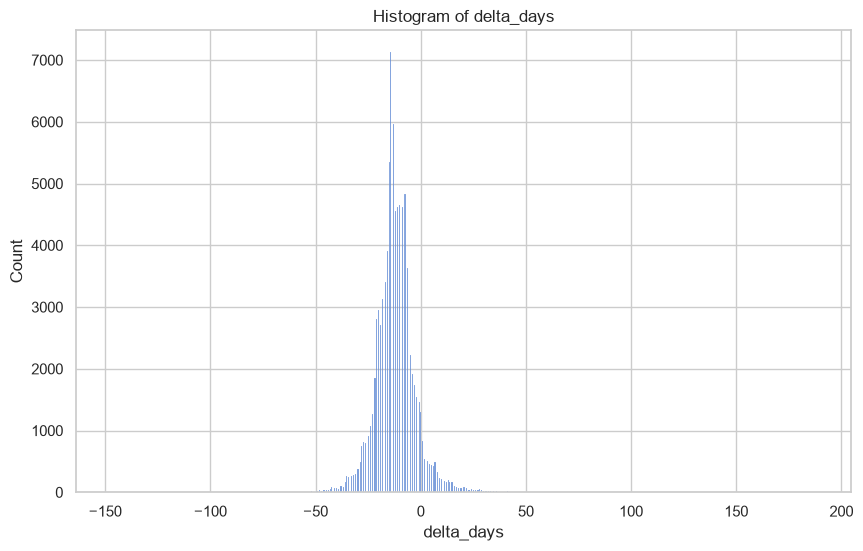

In [56]:
# visualização distribuição da variável-chave em histograma
plt.title('Histogram of delta_days')
sns.histplot(orders_delivered['delta_days'])
plt.show()

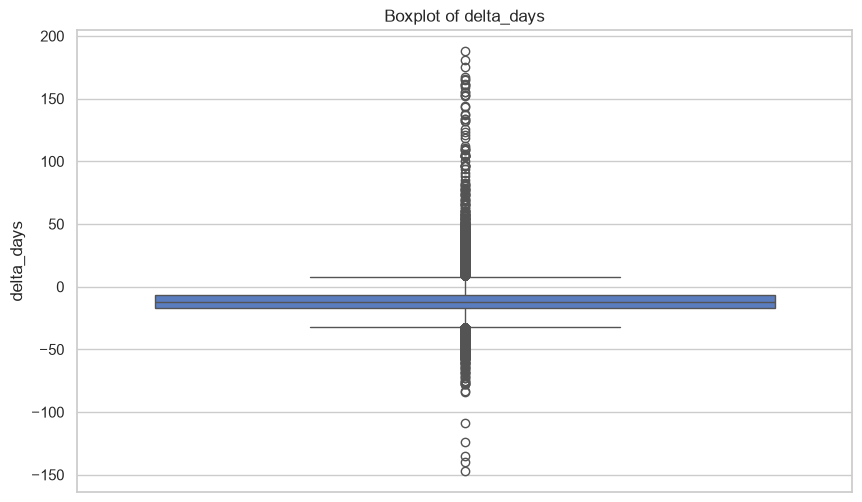

In [57]:
# visualização distribuição da variável-chave em boxplot
plt.title('Boxplot of delta_days')
sns.boxplot(orders_delivered['delta_days'])
plt.show()

A distribuição de `delta_days` revela uma operação estruturalmente antecipada:
- **Mediana: −12 dias** — metade das encomendas chegam 12 dias antes do previsto
- **P75: −7 dias** — 75% das encomendas chegam pelo menos 7 dias antes
- **Amplitude: −147 a +188 dias** — a cauda de atrasos extremos existe, mas é minoritária

A assimetria à direita e a concentração de valores negativos levantam uma questão relevante para as análises seguintes: os prazos estimados são sistematicamente conservadores, ou a operação logística é genuinamente eficiente? Esta questão será retomada na Análise 3 (geografia como factor estrutural).

### Consolidação de dados via SQL

Para responder à Pergunta 1, `delta_days` (calculado em `orders_delivered`) precisa de ser combinado com variáveis que estão noutras tabelas:

| Variável | Tabela de origem |
|---|---|
| `review_score` | `reviews` |
| `category_en` | `order_items` → `products` → `category_translation` |
| `order_value` | `payments` (soma de `payment_value` por pedido) |

Esta consolidação envolve joins entre 5 tabelas — razão pela qual foi feita em SQL (DuckDB), e não em pandas: a lógica relacional fica mais legível eauditável num ficheiro `.sql` separado.

#### Validações antes da query

Antes de escrever a query, foram feitas três verificações para antecipar perdas de linhas e tratar inconsistências:

In [58]:
# descoberta pedidos em orders_delivered que possuem review registrada
print(orders_delivered["order_id"].isin(reviews["order_id"]).value_counts())

order_id
True     95815
False      646
Name: count, dtype: int64


646 pedidos sem correspondência em reviews (serão excluídos pelo INNER JOIN)

In [59]:
# pedidos em orders_delivered que possuem payment registrada
print(orders_delivered["order_id"].isin(payments["order_id"]).value_counts())

order_id
True     96460
False        1
Name: count, dtype: int64


1 pedido sem correspondência em payments (será excluído pelo INNER JOIN)


In [60]:
# descoberta de pedidos com mais de uma review 
print(reviews['order_id'].duplicated().sum())

551


551 pedidos com mais de uma review. Tratamento: mantida a review mais recente por order_id (via ROW_NUMBER no SQL)


#### Execução da query e resultado

In [61]:
# criação função para leitura de arquivos sql externos
def load_query(filename):
    with open(f"../{filename}", encoding="utf-8") as f:
        return f.read() 

In [62]:
# importação dataframe resultante query sql q1
q1 = duckdb.sql(load_query("queries/q1_delay_category_value.sql")).df() 

In [63]:
# visualização df resultado query
q1.head()

,order_id,delta_days,review_score,category_en,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,-8,4,housewares,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,-6,4,perfumery,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,-18,5,auto,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,-13,5,pet_shop,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,-10,5,stationery,28.62


In [64]:
# informações df resultado query
q1.info()

<class 'pandas.DataFrame'>
RangeIndex: 95814 entries, 0 to 95813
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      95814 non-null  str    
 1   delta_days    95814 non-null  int64  
 2   review_score  95814 non-null  int64  
 3   category_en   95814 non-null  str    
 4   order_value   95814 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 3.7 MB


**Resultado:** 95.814 pedidos — sem valores nulos em nenhuma coluna.

Perda de 647 linhas em relação a `orders_delivered` (96.461):
- 646 pedidos sem correspondência em `reviews`
- 1 pedido sem correspondência em `payments`

Pedidos com `category_en = 'unknown'`: categorias nulas em `products` tratadas com `COALESCE` no SQL — mantidos na base para análises que não dependem de categoria.

In [65]:
# descoberta pedidos sem categoria identificada
print((q1["category_en"] == "unknown").sum())

1368


## **Q1 - Ponto de ruptura na Avaliação** 

— A partir de quantos dias de atraso a avaliação do cliente colapsa? A relação é linear ou existe um limiar crítico?

Investigação sobre a relação das variáveis `review_score` e `delta_days` 

### Filtro para pedidos atrasados

In [66]:
# filtro dataframe q1 para apenas pedidos atrasados
q1_delayed = q1[q1['delta_days'] > 0].copy()

In [67]:
# descoberta informações sobre dataframe q1_delayed
q1_delayed.info()

<class 'pandas.DataFrame'>
Index: 6380 entries, 18 to 95805
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      6380 non-null   str    
 1   delta_days    6380 non-null   int64  
 2   review_score  6380 non-null   int64  
 3   category_en   6380 non-null   str    
 4   order_value   6380 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 299.1 KB


6380 dos 95814 pedidos com review registrada foram entregues com atraso (~7%). 

A minoria numérica não diminui a relevância analítica: são exactamente estes pedidos que geram insatisfação, reclamações e impacto na reputação do vendedor.

### Visualização baseada em Delta de Dias

In [68]:
# agrupamento média de notas por dia de atraso
average_score_per_day = (
    q1_delayed.groupby('delta_days')['review_score']
    .mean()
    .reset_index()
)

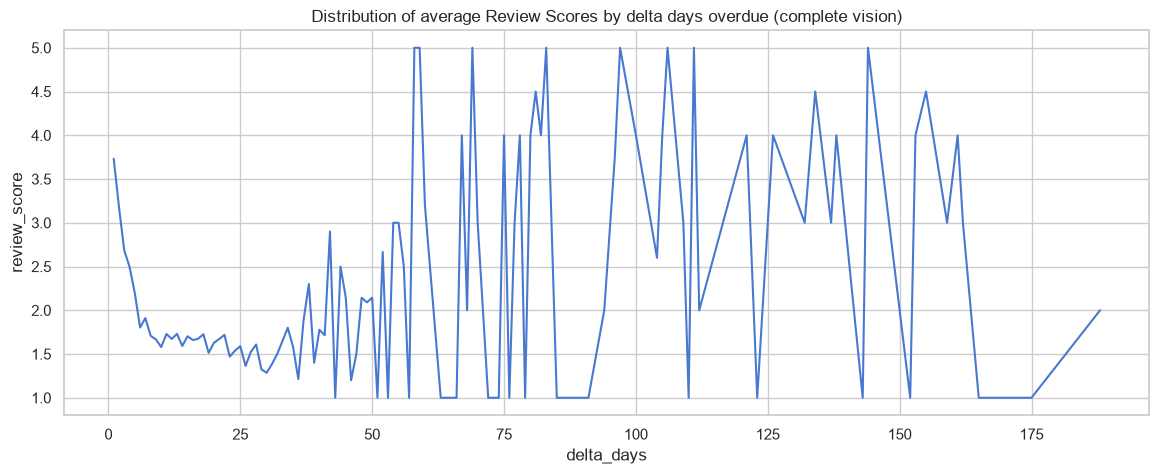

In [69]:
# visualização distribuição de review scores médios por dia de atraso
plt.figure(figsize=(14, 5))
sns.lineplot(data=average_score_per_day, x='delta_days', y='review_score')
plt.title('Distribution of average Review Scores by delta days overdue (complete vision)')
plt.show()

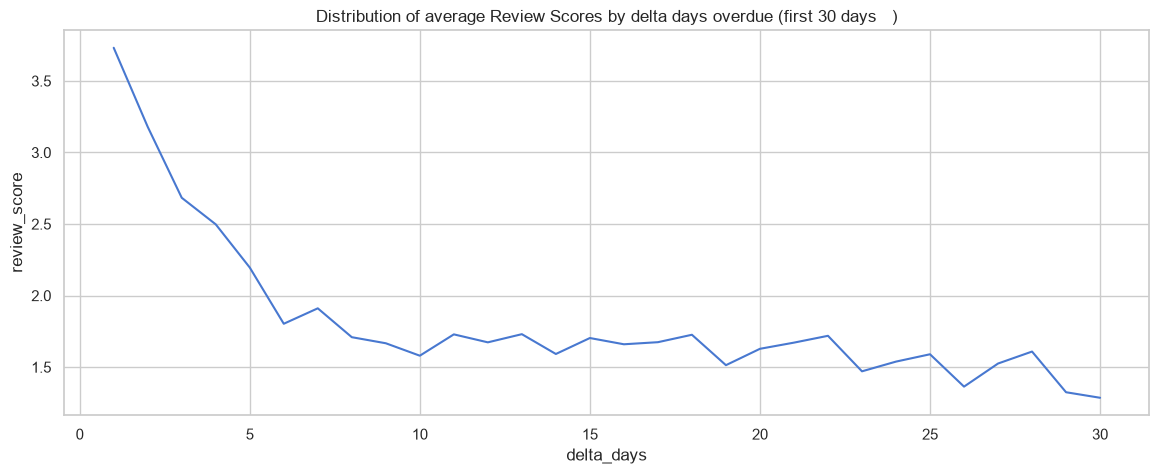

In [70]:
# visualização aproximada (30 dias) da distribuição de review scores médios por dia de atraso
plt.figure(figsize=(14, 5))
sns.lineplot(data=average_score_per_day[average_score_per_day['delta_days'] < 31], x='delta_days', y='review_score')
plt.title('Distribution of average Review Scores by delta days overdue (first 30 days   )')
plt.show()

A nota média cai de vertiginosamente dentro dos primeiros 6-7 dias de atraso, de ~3.5 para ~2.0. 

É constatada uma mudança de score de ~3.5 para ~1.5 ao fim de 15 dias de atraso.

### Visualização baseada em proporção de avaliações baixas

In [71]:
# criação coluna faixas de atraso
q1_delayed['delta_bin'] = pd.cut(
    q1_delayed['delta_days'],
    bins=range(0, q1_delayed['delta_days'].max() + 5, 5),
    right=False
)

In [72]:
# agrupamento de número de pedidos consoante as faixas de atraso
orders_per_bin = q1_delayed.groupby('delta_bin')['order_id'].nunique().reset_index(name='n_orders')

Com 6.380 pedidos espalhados por ~33 bins, há bins com pouquíssimas observações — especialmente a partir de [60, 65) em diante. 

Isto explica o comportamento errático no gráfico: a partir de ~60 dias, os picos e vales extremos (100% de nota 1, depois 20%, depois 100% outra vez) não reflectem um padrão real — reflectem bins com 2, 3 ou 5 observações, onde 1 cliente insatisfeito move a proporção 20-50 pontos percentuais.

In [73]:
# agrupamento de proporções de reviews score 1 por faixa de atraso 
score1_proportion = (
    q1_delayed.groupby('delta_bin', observed=True)
    .apply(lambda x: (x['review_score'] == 1).sum() / len(x))
    .reset_index(name='score1_proportion')
)

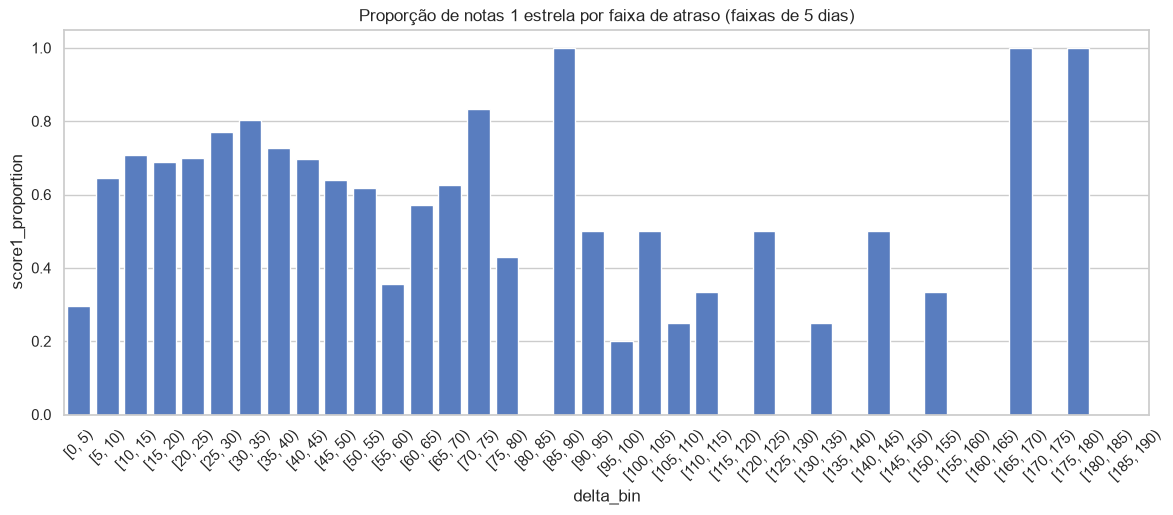

In [74]:
# visualização proporção de reviews score 1 por faixa de atraso
plt.figure(figsize=(14, 5))
sns.barplot(data=score1_proportion, x='delta_bin', y='score1_proportion')
plt.xticks(rotation=45)
plt.title("Proporção de notas 1 estrela por faixa de atraso (faixas de 5 dias)")
plt.show()

A proporção de notas 1 estrela salta de ~30% em `[0,5)` para ~65-70% já em `[5,10)`.

Já em `[25,30)`, a proporção de notas 1 está próxima de 80%. 

Nos bins acima de 60 dias, os valores extremos (0% ou 100%) são ruído de amostra e não devem ser interpretados.

### Análise zona crítica (primeiros 30 dias)

In [75]:
# criação dataframe zona crítica - menores que 30 dias de atraso
critical_zone = q1_delayed[q1_delayed['delta_days'] <= 30].copy()

In [76]:
# criação agregado com review médio, número de pedidos e proporção de score 1 em avaliações com base em cada delta day dentro da zona critica 
agg_critical_zone = (
    critical_zone.groupby('delta_days')
    .agg(
        avg_review=("review_score", "mean"),
        n_orders=("review_score", "count"),
        score1_proportion=("review_score", lambda x: (x == 1).sum() / len(x))
    )
    .reset_index()
)

agg_critical_zone

,delta_days,avg_review,n_orders,score1_proportion
0,1,3.73,820,0.13
1,2,3.18,536,0.27
2,3,2.68,496,0.43
3,4,2.50,436,0.48
4,5,2.20,434,0.55
5,6,1.80,406,0.69
6,7,1.91,471,0.63
7,8,1.71,330,0.69
8,9,1.67,219,0.72
9,10,1.58,207,0.72


A queda ocorre em duas fases:

**Fase 1 — Deterioração progressiva (dias 1 a 5)**
A nota cai de 3.73 para 2.20 e a proporção de nota 1 sobe de 13% para 55%.
O cliente ainda *diferencia* níveis de atraso — um atraso de 1 dia é tratado 
de forma claramente diferente de um atraso de 5 dias.

**Fase 2 — Colapso e estabilização (a partir do dia 6)**
A nota cai abruptamente para ~1.8 e estabiliza entre 1.5–1.7 
indefinidamente. A partir daqui o cliente deixa de diferenciar: 
6 dias ou 30 dias de atraso produzem o mesmo nível de insatisfação.

### Teste Estatístico - Distribuição em Faixas de Atraso

Validação estatística do limiar — dia 6

O limiar foi identificado exploratoriamente pela queda abrupta na nota média e na proporção de nota 1 exactamente no dia 6. Para confirmar que a diferença entre os dois grupos definidos por esse limiar é
estatisticamente significativa, aplica-se Mann-Whitney comparando a distribuição de `review_score` entre:

- **grupo `late`:** pedidos com `delta_days` entre 1 e 5
- **grupo `late_critical`:** pedidos com `delta_days` entre 6 e 30

**H₀ (nula):** a distribuição de `review_score` é igual entre os dois grupos 

**H₁ (alternativa):** a distribuição de `review_score` difere entre os dois grupos

Nível de significância: α = 0.05

In [162]:
# filtro: grupo late (delta_days 1-5) vs grupo late_critical (delta_days 6-30)
grupo_late = critical_zone[critical_zone['delta_days'] <= 5]['review_score'].values
grupo_late_critical = critical_zone[critical_zone['delta_days'] >= 6]['review_score'].values
print(f'Grupo late (1-5 dias): {len(grupo_late)}')
print(f'Grupo late_critical (6-30 dias): {len(grupo_late_critical)}')

Grupo late (1-5 dias): 2722
Grupo late_critical (6-30 dias): 3330


In [163]:
# aplicação teste Mann-Whitney para definir se a distribuição de review_score difere entre os dois grupos
stat, p_value = st.mannwhitneyu(grupo_late, grupo_late_critical, alternative='two-sided')

print(f"\nMann-Whitney U={stat:.2f}, p={p_value:.4f}")
print(f"Significativo (α=0.05): {p_value < 0.05}")


Mann-Whitney U=6460483.50, p=0.0000
Significativo (α=0.05): True


#### Resultado da validação estatística

| teste | p-value | rejeita H₀? |
|---|---|---|
| Mann-Whitney — `late` (n=2.722) vs `late_critical` (n=3.330) | <0.0001 | ✓ Sim |

A diferença de distribuição de `review_score` entre os grupos `late` (1–5 dias) e `late_critical` (≥6 dias) é estatisticamente significativa.
O limiar identificado exploratoriamente no dia 6 é confirmado estatisticamente: os dois grupos têm distribuições de avaliação distintas, e a separação não resulta de ruído de amostra.

### Conclusões - O limiar está no dia 6

A queda ocorre em duas fases distintas:

**Fase 1 — Deterioração progressiva (dias 1 a 5)**
A nota cai de 3.73 para 2.20 e a proporção de nota 1 sobe de 13% para 55%. O cliente ainda diferencia níveis de atraso.

**Fase 2 — Colapso e estabilização (a partir do dia 6)**
A nota cai abruptamente para ~1.8 e estabiliza entre 1.5 – 1.7 indefinidamente. O cliente deixa de diferenciar — 6 dias ou 30 dias produzem o mesmo nível de insatisfação.

A separação entre os dois grupos é estatisticamente robusta (Mann-Whitney U=6.460.483.5, p<0.0001), confirmando que o limiar identificado exploratoriamente não resulta de ruído de amostra.

> **Implicação operacional:** uma transportadora que entrega com 6 dias de atraso está no lado errado do limiar. Reduzir de 8 para 6 dias não resolve o problema — reduzir de 6 para 5 dias pode fazer toda a diferença.

### Classificação dos pedidos: `delay_status`

Com o limiar empiricamente identificado, é possível criar uma variável categórica que será reutilizada nas análises seguintes.

In [77]:
# criação função de classificação dos atrasos
def classify_delay(delta):
    if delta < 0:
        return "early"
    elif delta == 0:
        return "on_time"
    elif delta <= 5:
        return 'late' # deterioração progressiva — cliente ainda diferencia
    elif delta <= 30:
        return 'late_critical' # colapso — nota estabiliza em ~1.6
    else:
        return 'late_extreme' # volume muito baixo — tratar com cautela

In [78]:
# aplicação função de classificação
q1['delay_status'] = q1['delta_days'].apply(classify_delay)

In [79]:
print(q1['delay_status'].value_counts())

delay_status
early            88154
late_critical     3330
late              2722
on_time           1280
late_extreme       328
Name: count, dtype: int64


**Observação:** `late_extreme` (>30 dias, 328 pedidos, ~0.3%) será incluído em visualizações gerais mas não interpretado em subgrupos — o volume é insuficiente para segmentações por categoria ou estado sem risco elevado de ruído de amostra.

## **Q2 - Assimetria do Atraso por Categoria e Valor** 

O mesmo atraso produz o mesmo impacto na avaliação diferente independentemente do contexto? Um atraso de 5 dias em `product_category` de alta expectativa (beleza, moda) vs baixa expectativa (ferramentas, construção) penaliza igual? 

Quais categorias e faixas de valor concentram os maiores atrasos? O atraso distribui-se de forma uniforme ou há padrões específicos?

### Investigação váriavel - `order_value`

In [80]:
# características variável order_value
q1['order_value'].describe()

count   95814.00
mean      159.59
std       217.52
min         9.59
25%        61.84
50%       105.28
75%       176.16
max     13664.08
Name: order_value, dtype: float64

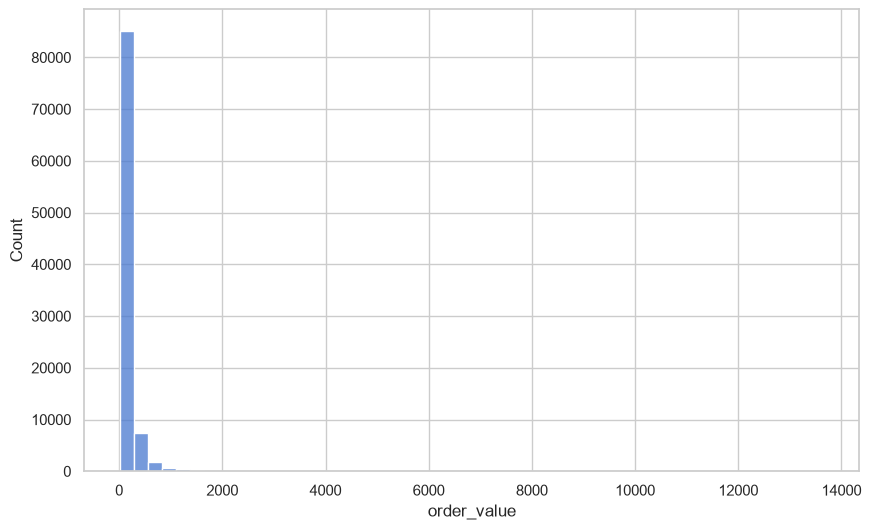

In [81]:
# visualização da distribuição de order_value 
sns.histplot(q1['order_value'], bins=50)
plt.show()

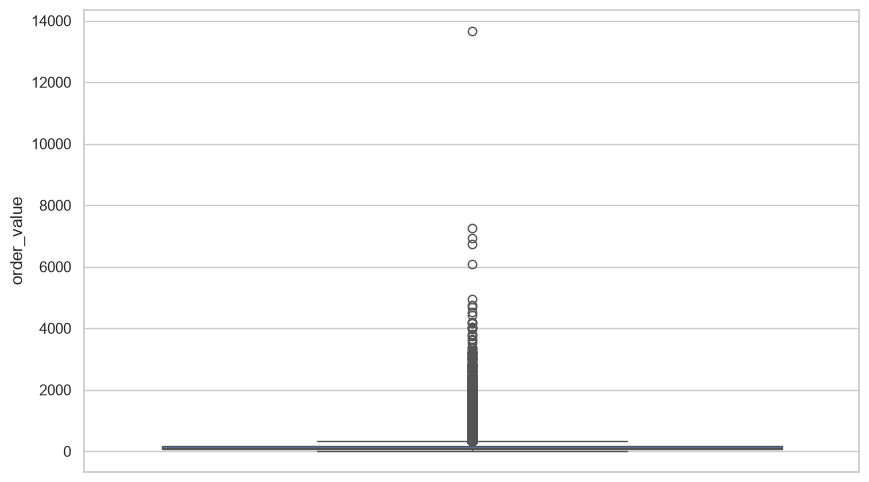

In [82]:
# visualização da distribuição de order_value 
sns.boxplot(q1['order_value'])
plt.show()

O histograma mostra distribuição fortemente assimétrica à direita. A grande maioria dos pedidos concentra-se abaixo de R$500, com uma cauda longa até R$13.664.

### Criação de variável - `value_tier`

In [83]:
# descoberta cauda (P99) da variável `order_values` 
print(q1['order_value'].quantile(0.99))

1048.5361999999986


In [84]:
# criação coluna `value_tier` com base em percentis visualizados
q1['value_tier'] = pd.cut(
    q1['order_value'],
    bins=[0, 61.84, 105.28, 176.16, 1048.54, 13664.08],
    labels=['low', 'medium_low', 'medium', 'high', 'premium'],
    include_lowest=True
)   

In [85]:
# visualização distribuição de valores 
print(q1['value_tier'].value_counts().sort_index())

value_tier
low           23966
medium_low    24034
medium        23863
high          22992
premium         959
Name: count, dtype: int64


`value_tier` definido por quartis de `order_value`, com isolamento do P99 como tier `premium`:

| tier | limite | n pedidos |
|---|---|---|
| low | ≤ R$61.84 | ~24k |
| medium_low | ≤ R$105.28 | ~24k |
| medium | ≤ R$176.16 | ~24k |
| high | ≤ R$1.048.54 | ~23k |
| premium | > R$1.048.54 | ~959 |

Os quatro tiers base têm volumes equilibrados por construção (quartis), o que garante que comparações entre grupos não são distorcidas por diferenças de volume. O tier `premium` tem volume reduzido mas significado analítico distinto — pedidos acima de R$1.048 representam 1% do total e podem ter perfil de insatisfação diferente dos restantes.

### Volume de atrasos por categoria

In [86]:
# criação agregado de número de pedidos atrasados e review médio para cada categoria de produto
volume_category = (
    q1[q1['delay_status'].isin(['late', 'late_critical'])]
    .groupby('category_en')
    .agg(
        n_delayeds=('order_id', 'count'),
        average_review=('review_score', 'mean'),
        score1_proportion=('review_score', lambda x: (x == 1).sum() / len(x))

    )
    .sort_values('n_delayeds', ascending=False)
    .reset_index()
)

In [87]:
# visualização top 20 resultados das categorias com maior número de atrasadas 
volume_category.head(20)

,category_en,n_delayeds,average_review,score1_proportion
0,bed_bath_table,626,2.23,0.55
1,health_beauty,603,2.37,0.51
2,sports_leisure,460,2.18,0.59
3,furniture_decor,406,2.34,0.50
4,computers_accessories,389,2.30,0.53
5,watches_gifts,384,2.19,0.54
6,housewares,287,2.26,0.54
7,telephony,276,2.45,0.47
8,auto,254,2.29,0.56
9,toys,219,2.12,0.59


A variação de `average_review` entre as 20 categorias com mais atrasos é pequena — vai de 2.05 (baby) a 2.45 (telephony), uma amplitude de apenas 0.40 pontos percentuais.

Quanto a variação de `score1_proportion` entre as 20 categorias com mais atrasos é pequena - de 47% (telephony) a 61% (baby), diferença de ~14 pontos percentuais.

### Volume de atrasos por categoria e tipo de atraso

In [88]:
# criação agregado de número de pedidos atrasados, review médio para cada categoria de produto e delay_status
volume_category_status = (
    q1[q1['delay_status'].isin(['late', 'late_critical'])]
    .groupby(['category_en', 'delay_status'])
    .agg(
        n_delayeds=('order_id', 'count'),
        average_review=('review_score', 'mean'),
        score1_proportion=('review_score', lambda x: (x == 1).sum() / len(x))
    )
    .reset_index()
    .sort_values(['delay_status', 'n_delayeds'], ascending=[True, False])
)

In [89]:
# top 10 categorias por volume
top10 = volume_category.head(10)['category_en']

# visualização do agregado baseado em top 10 categorias com maiores atrasados
print(
    volume_category_status[
        volume_category_status['category_en'].isin(top10)
    ].to_string()
)

               category_en   delay_status  n_delayeds  average_review  score1_proportion
13          bed_bath_table           late         275            2.93               0.37
76           health_beauty           late         273            3.21               0.29
112         sports_leisure           late         192            2.83               0.42
68         furniture_decor           late         186            3.02               0.30
26   computers_accessories           late         178            3.12               0.29
123          watches_gifts           late         172            2.87               0.34
117              telephony           late         137            3.12               0.27
87              housewares           late         129            2.98               0.33
9                     auto           late         118            3.12               0.33
119                   toys           late          84            2.62               0.46
14          bed_bath_

### Visualizações baseadas em Categoria

In [90]:
# ordenação por score médio de review dentro de late para destacar diferenciação
order_late = (
    volume_category_status[
        (volume_category_status['category_en'].isin(top10)) & 
        (volume_category_status['delay_status'] == 'late')
        ]
    .sort_values('average_review', ascending=False)['category_en']
)

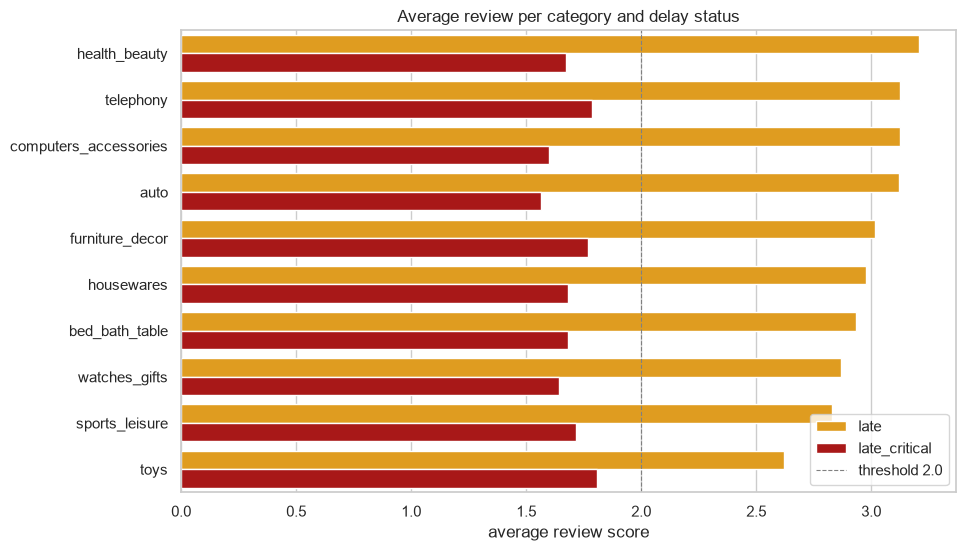

In [91]:
# gráfico 1 — nota média por categoria e estado do atraso
sns.barplot(
    data=volume_category_status[volume_category_status['category_en'].isin(top10)],
    x='average_review',
    y='category_en',
    hue='delay_status',
    order=order_late,
    palette={'late': '#FFA500', 'late_critical': '#C00000'},
    )
plt.title('Average review per category and delay status')
plt.ylabel('')
plt.xlabel('average review score')
plt.axvline(
    x=2,
    color='gray',
    linestyle='--',
    linewidth=0.8,
    label='threshold 2.0')
plt.legend()
plt.show()

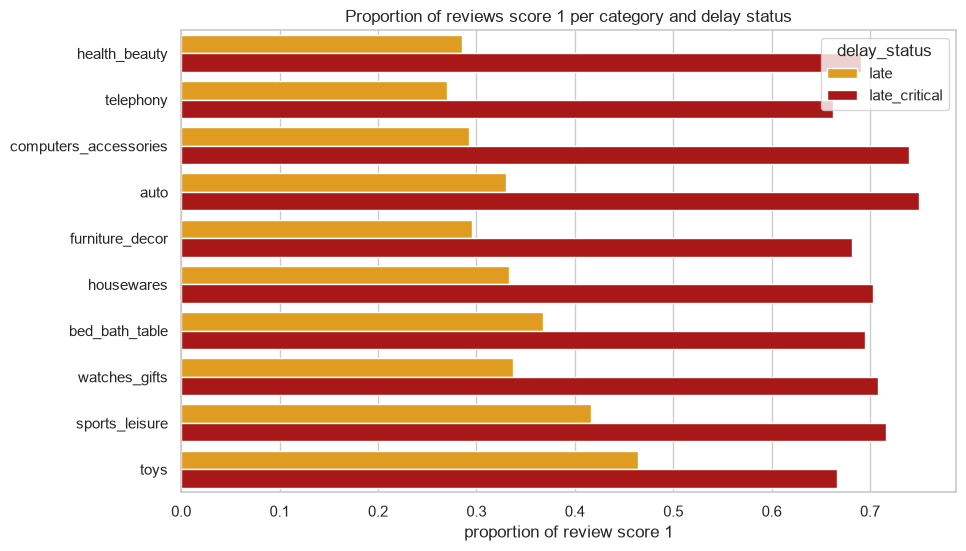

In [92]:
# gráfico 2 — proporção nota 1 por categoria e estado do atraso
sns.barplot(
    data=volume_category_status[volume_category_status['category_en'].isin(top10)],
    x='score1_proportion',
    y='category_en',
    hue='delay_status',
    order=order_late,
    palette={'late': '#FFA500', 'late_critical': '#C00000'},
    )
plt.title('Proportion of reviews score 1 per category and delay status')
plt.ylabel('')
plt.xlabel('proportion of review score 1')
plt.show()

Os dois gráficos confirmam visualmente o padrão identificado nos dados:

**`late_critical` (vermelho):** banda compacta e uniforme — nota média ~1.6–1.8 e proporção de nota 1 ~65–75% em todas as categorias. A categoria deixa de ser um factor diferenciador a partir do dia 6 de atraso.

**`late` (azul):** variação clara entre categorias. `health_beauty` e `telephony` mantêm nota média acima de 3.0 com menos de 30% de nota 1 — são as categorias mais tolerantes a atrasos curtos. `toys` e `sports_leisure` penalizam mais fortemente (nota ~2.6 e ~46% de nota 1) mesmo dentro de 1–5 dias de atraso.

A linha tracejada no limiar 2.0 ilustra a separação entre as duas fases: todas as barras azuis estão acima de 2.0; todas as vermelhas estão abaixo.

### Testes estatísticos — Distribuição em Categoria

#### Aplicação Mann Whitney

In [93]:
# seleção de categorias extremas em média de review_score e score1_proportion com base em de estado de atraso 'late'
relevants = [
    ('health_beauty', 'toys'),
    ('health_beauty', 'sports_leisure'),
    ('telephony', 'toys'),
    ('telephony', 'sports_leisure')
]

In [94]:
# filtro dentro de estado de atraso 'late' e maiores volumes de pedidos
late_by_category = q1[
    (q1['delay_status'] == 'late') & 
    (q1['category_en'].isin(top10))
] 

In [95]:
results = []

# aplicação de teste mann whitney em review_score das categorias relevantes
for category1, category2 in relevants:
    g1 = late_by_category[late_by_category['category_en'] == category1]['review_score'].values
    g2 = late_by_category[late_by_category['category_en'] == category2]['review_score'].values
    stat, p_value = st.mannwhitneyu(g1, g2, alternative='two-sided')
    results.append({
        'category1': category1,
        'category2': category2,
        'p_value': round(p_value, 4),
        'significative': p_value < 0.05
    })

test_results = pd.DataFrame(results)
print(test_results.to_string())

       category1       category2  p_value  significative
0  health_beauty            toys     0.01           True
1  health_beauty  sports_leisure     0.02           True
2      telephony            toys     0.04           True
3      telephony  sports_leisure     0.15          False


In [96]:
test_results['p_bonferroni'] = test_results['p_value'] * 4
test_results['significative_bonferroni'] = test_results['p_bonferroni'] < 0.05
print(test_results.to_string())

       category1       category2  p_value  significative  p_bonferroni  significative_bonferroni
0  health_beauty            toys     0.01           True          0.02                      True
1  health_beauty  sports_leisure     0.02           True          0.06                     False
2      telephony            toys     0.04           True          0.15                     False
3      telephony  sports_leisure     0.15          False          0.61                     False


**Hipóteses e resultados dos testes Mann-Whitney**

Para cada par de categorias, testamos se a distribuição de `review_score` no grupo `late` (1–5 dias de atraso) é igual entre as duas categorias.

**H₀ (nula):** a distribuição de `review_score` é igual entre as duas categorias

**H₁ (alternativa):** a distribuição de `review_score` difere entre as duas categorias

Nível de significância: α = 0.05

| par | U | p-value | rejeita H₀? |
|---|---|---|---|
| `health_beauty` vs `toys` | 13676.0 | 0.01 | ✓ Sim |
| `health_beauty` vs `sports_leisure` | 29521.5 | 0.02 | ✓ Sim |
| `telephony` vs `toys` | 6687.0 | 0.04 | ✓ Sim |
| `telephony` vs `sports_leisure` | 14321.0 | 0.15 | ✗ Não |

3 dos 4 pares rejeitam H₀ a α=0.05 — indicando que, antes de qualquer correcção para múltiplas comparações, há evidência de diferença entre as categorias mais tolerantes (`health_beauty`, `telephony`) e as mais penalizadas (`toys`, `sports_leisure`).

O único par que não rejeita H₀ é `telephony` vs `sports_leisure` (p=0.15), sugerindo que a diferença observada nas médias entre estas duas categorias específicas não é estatisticamente distinguível do ruído de amostra.

**Nota:** como foram realizadas 4 comparações simultâneas sobre o mesmo conjunto de dados, os p-values acima estão sujeitos ao problema de comparações múltiplas — corrigido na secção seguinte com o método de Bonferroni.

#### Validação estatística — Mann-Whitney com correcção de Bonferroni

Para confirmar se as diferenças observadas entre categorias no grupo `late` são estatisticamente significativas, foram realizados testes Mann-Whitney nos 4 pares extremos identificados na análise exploratória.

| par | p (Bonferroni) | significativo |
|---|---|---|
| health_beauty vs toys | 0.02 | ✓ |
| health_beauty vs sports_leisure | 0.06 | ✗ |
| telephony vs toys | 0.15 | ✗ |
| telephony vs sports_leisure | 14321.0 | 0.61 | ✗ |

Apenas o par `health_beauty` vs `toys` mantém significância estatística após correcção de Bonferroni (p=0.02). Os restantes pares não atingem o limiar ajustado de 0.0125 — o que reflecte, em parte, o volume limitado de pedidos nas categorias mais penalizadas (`toys`: 84 pedidos, `sports_leisure`: 192 pedidos no grupo `late`).

**Conclusão ajustada:** a diferença entre `health_beauty` e `toys` no grupo `late` é estatisticamente robusta. As restantes diferenças observadas nas médias são sugestivas mas não conclusivas com o volume disponível — requerendo validação com um dataset de maior dimensão.

### Conclusão parcial: a assimetria existe — mas numa janela estreita

Dois padrões são claros:

**`late_critical` (≥6 dias): colapso uniforme** 
Todas as categorias convergem para review médio ~1.6–1.8 e proporção de nota 1 ~66–75%. A categoria deixa de ser um factor diferenciador — o cliente já está insatisfeito independentemente do que comprou.

**`late` (1–5 dias): janela de diferenciação**
É aqui que a categoria importa. `toys` (46% de nota 1) e `sports_leisure` (42%) são significativamente mais penalizados do que `health_beauty` (29%) ou `telephony` (27%) para o mesmo intervalo de atraso.

A validação estatística confirma parcialmente este padrão: o par `health_beauty` vs `toys` mantém significância após correcção de Bonferroni (p=0.02), sendo a diferença mais robusta identificada. Os restantes pares são sugestivos mas não conclusivos com o volume disponível — a diferença observada entre `telephony` e `sports_leisure`, por exemplo, não é estatisticamente distinguível do ruído (p=0.61 após correcção).

Uma hipótese plausível: categorias associadas a ocasiões com data específica (brinquedos para aniversários, equipamento desportivo para eventos) têm menor tolerância a qualquer atraso — mas esta hipótese requereria validação com dados adicionais sobre sazonalidade ou motivação de compra, que não estão disponíveis neste dataset.

> **Síntese:** O atraso não é simétrico — mas a janela de diferenciação entre categorias é estreita: apenas nos primeiros 5 dias. Acima de 6 dias, > o contexto da compra deixa de importar. A diferença estatisticamente robusta concentra-se no par `health_beauty` vs `toys` — os restantes pares são indicativos mas requerem maior volume para confirmação.

### Volume de atrasos por valor do pedido e atraso

In [97]:
volume_value_status = (
    q1[q1['delay_status'].isin(['late', 'late_critical'])]
    .groupby(['value_tier', 'delay_status'])
    .agg(
        n_delayeds=('order_id', 'count'),
        average_review=('review_score', 'mean'),
        score1_proportion=('review_score', lambda x: (x==1).sum() / len(x))
    )
    .reset_index()
    .sort_values(['delay_status', 'average_review'], ascending=[True, False])
)

print(volume_value_status.to_string())

   value_tier   delay_status  n_delayeds  average_review  score1_proportion
8     premium           late          26            3.23               0.35
0         low           late         645            3.07               0.31
4      medium           late         700            3.00               0.33
2  medium_low           late         671            2.96               0.35
6        high           late         680            2.91               0.36
1         low  late_critical         650            1.75               0.68
3  medium_low  late_critical         834            1.74               0.68
5      medium  late_critical         863            1.73               0.67
7        high  late_critical         936            1.64               0.72
9     premium  late_critical          47            1.19               0.87


O valor do pedido é um amplificador de insatisfação. Nas categorias, o colapso era uniforme acima de 6 dias — no valor, não: clientes de pedidos premium (>R$1.048) atrasados penalizam com 87% de nota 1, contra 68% nos pedidos de baixo valor. A expectativa cresce com o valor pago.

### Visualizações baseadas em Faixa de Valor

In [98]:
# ordenação value_tier do menor para o maior valor
tier_order = ['low', 'medium_low', 'medium', 'high', 'premium']

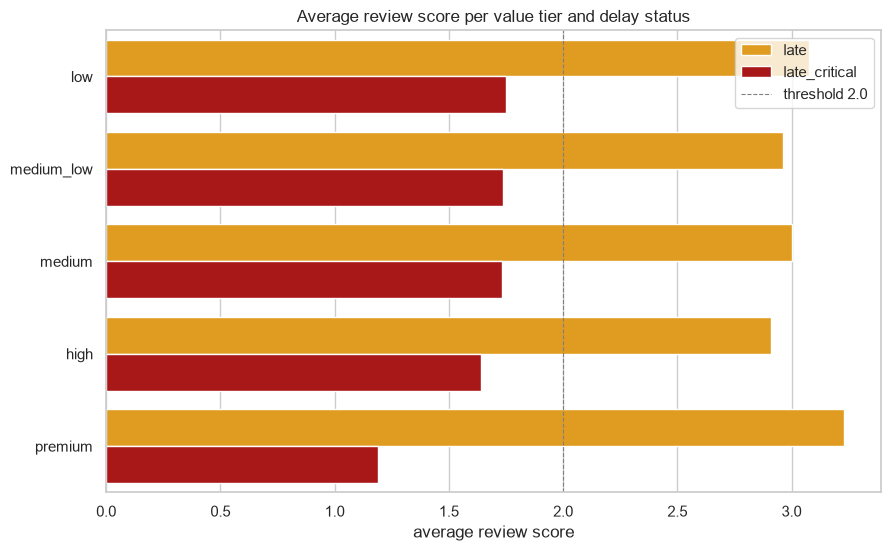

In [99]:
# gráfico 1 — nota média por faixa de preço e estado do atraso
sns.barplot(
    data=volume_value_status,
    x='average_review',
    y='value_tier',
    hue='delay_status',
    order=tier_order,
    palette={'late': '#FFA500', 'late_critical': '#C00000'},
)
plt.title('Average review score per value tier and delay status')
plt.xlabel('average review score')
plt.ylabel('')
plt.axvline(
    x=2.0,
    color='gray',
    linestyle='--',
    linewidth='0.8',
    label='threshold 2.0'
    )
plt.legend()
plt.show()

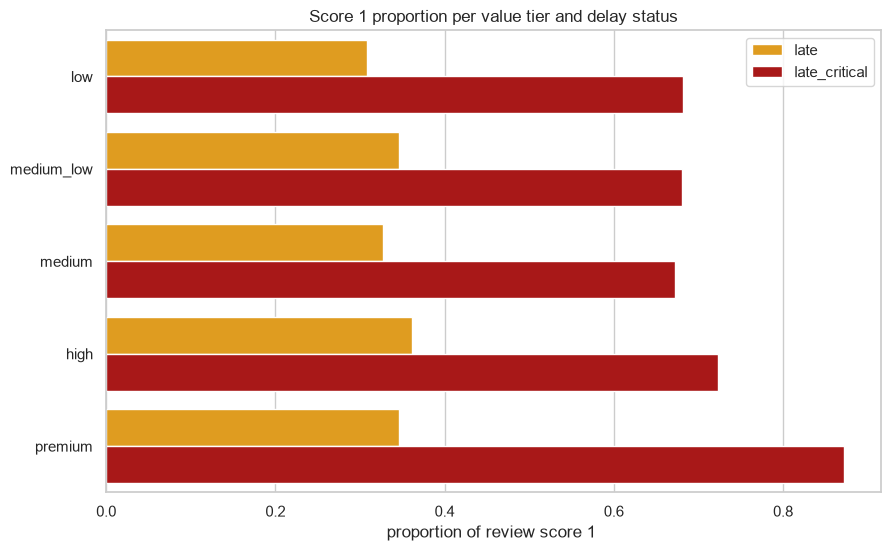

In [100]:
# gráfico 2 — nota média por faixa de preço e estado do atraso
sns.barplot(
    data=volume_value_status,
    x='score1_proportion',
    y='value_tier',
    hue='delay_status',
    order=tier_order,
    palette={'late': '#FFA500', 'late_critical': '#C00000'},
)
plt.title('Score 1 proportion per value tier and delay status')
plt.xlabel('proportion of review score 1 ')
plt.ylabel('')
plt.legend()
plt.show()

### Testes estatísticos — Distribuição em Faixa de Valor

#### Aplicação Kruskal test

O `review_score` é uma variável ordinal (1 a 5), não contínua nem normalmente distribuída — o que exclui ANOVA e t-test. O teste adequado para comparar distribuições ordinais entre três ou mais grupos independentes é o **Kruskal-Wallis**: uma alternativa não-paramétrica à ANOVA que testa se pelo menos um grupo tem distribuição diferente dos restantes.

Como o atraso tem dois comportamentos distintos (`late` e `late_critical`), o teste é aplicado separadamente a cada grupo — permitindo verificar se o valor do pedido é um factor diferenciador em ambas as fases ou apenas numa delas.

**H₀ (nula):** a distribuição de `review_score` é igual entre todos os tiers de valor

**H₁ (alternativa):** pelo menos um tier tem distribuição de `review_score` diferente dos restantes

Nível de significância: α = 0.05

Se o Kruskal-Wallis rejeitar H₀, aplica-se Mann-Whitney par a par nos pares relevantes com correcção de Bonferroni para controlar o erro de Tipo I resultante de múltiplas comparações.

In [101]:
# filtro por delay_status
late_value = q1[q1['delay_status'] == 'late']
late_critical_value = q1[q1['delay_status'] == 'late_critical']

In [102]:
# variável isolada para cada delay_status
tiers = ['low', 'medium_low', 'medium', 'high', 'premium']

In [105]:
# grupos por tier para cada delay_status
groups_late = []
groups_late_critical = []

for t in tiers:
    group = late_value[late_value['value_tier'] == t]['review_score'].values
    groups_late.append(group)

for t in tiers:
    group = late_critical_value[late_critical_value['value_tier'] == t]['review_score'].values
    groups_late_critical.append(group)
    

In [106]:
# aplicação teste estatístico Kruskal Wallis 
stat_late, p_late = st.kruskal(*groups_late)
stat_lc, p_lc = st.kruskal(*groups_late_critical)

In [107]:
# descoberta resultados teste estatístico
print(f"Kruskal-Wallis — late:          H={stat_late:.4f}, p={p_late:.4f}")
print(f"Kruskal-Wallis — late_critical: H={stat_lc:.4f},  p={p_lc:.4f}")

Kruskal-Wallis — late:          H=3.9695, p=0.4101
Kruskal-Wallis — late_critical: H=14.0998,  p=0.0070


**Kruskal-Wallis — teste global**

| grupo | p-value | rejeita H₀? |
|---|---|---|
| `late` (1–5 dias) | 0.41 | ✗ Não |
| `late_critical` (≥6 dias) | 0.007 | ✓ Sim |

No grupo `late`, o valor do pedido não é um factor diferenciador — a distribuição de `review_score` é estatisticamente equivalente entre todos os tiers. 

No grupo `late_critical`, há diferença significativa entre pelo menos um par de tiers.

#### Aplicação Mann-Whitney e correção Bonferroni

In [108]:
# seleção de faixas de valor para comparação
pares_value = [
    ('low', 'premium'),
    ('high', 'premium'),
    ('low', 'high')
]

In [109]:
results_value = []

# aplicação de teste estatístico Mann Whitney
for tier1, tier2 in pares_value:
    g1 = late_critical_value[late_critical_value['value_tier'] == tier1]['review_score'].values
    g2 = late_critical_value[late_critical_value['value_tier'] == tier2]['review_score'].values
    stat, p_value = st.mannwhitneyu(g1, g2, alternative='two-sided')
    results_value.append({
        'tier1': tier1,
        'tier2': tier2,
        'U': round(stat, 2),
        'p_value': round(p_value, 4),
        'significative': p_value < 0.05
    })

test_results_value = pd.DataFrame(results_value)

In [110]:
# correcção de Bonferroni (3 comparações)
test_results_value['p_bonferroni'] = test_results_value['p_value'] * 3
test_results_value['significative_bonferroni'] = test_results_value['p_bonferroni'] < 0.05

print(test_results_value.to_string())

  tier1    tier2         U  p_value  significative  p_bonferroni  significative_bonferroni
0   low  premium  18450.50     0.00           True          0.01                      True
1  high  premium  25594.00     0.02           True          0.05                      True
2   low     high 317262.00     0.07          False          0.21                     False


#### Hipóteses e resultados dos testes — `value_tier`

**H₀ (nula):** a distribuição de `review_score` é igual entre os tiers de valor

**H₁ (alternativa):** a distribuição de `review_score` difere entre os tiers de valor

Nível de significância: α = 0.05

**Mann-Whitney par a par — `late_critical` com correcção de Bonferroni**

| par | p-value | p (Bonferroni) | significativo |
|---|---|---|---|
| `low` vs `premium` | 0.00 | 0.01 | ✓ Sim |
| `high` vs `premium` | 0.02 | 0.05 | ✓ Sim |
| `low` vs `high` | 0.07 | 0.21 | ✗ Não |

O tier `premium` é estatisticamente distinto de `low` e `high` após correcção de Bonferroni. A diferença entre `low` e `high` — apesar de visível nas médias (1.75 vs 1.64) — não é estatisticamente significativa, indicando que o gradiente observado nos tiers intermédios é ruído de amostra.

### Conclusão: o `premium` como amplificador — não o valor em geral

Os testes estatísticos refinam a conclusão da análise exploratória: 
o valor do pedido **não** amplifica a insatisfação de forma linear. O que amplifica é especificamente o tier `premium` (>R$1.048), e apenas quando combinado com atraso crítico (≥6 dias).

Os tiers `low`, `medium_low`, `medium` e `high` — apesar de cobrirem uma amplitude de R$9 a R$1.048 — são estatisticamente equivalentes na sua reacção ao atraso. A fronteira crítica não está entre pedidos baratos e caros: está entre pedidos normais e pedidos de valor
excepcionalmente elevado.

> **Síntese da Análise 1:**
> O atraso não é simétrico em duas dimensões:
>
> — **Categoria:** a diferença estatisticamente robusta concentra-se no par `health_beauty` vs `toys` no grupo `late`. Acima de 6 dias, todas as categorias colapsam uniformemente.
>
> — **Valor:** o tier `premium` é o único estatisticamente distinto dos restantes, e apenas no `late_critical`. O gradiente de valor observado nos tiers intermédios não é estatisticamente significativo.
>
> A combinação mais crítica permanece: pedido `premium` + atraso ≥6 dias.

## **Q3 - Geografia como Fator Estrutural** 

Os atrasos resultam de logística lenta ou de janelas de entrega irrealistas? Será que a resposta varia por estado ou região?

### Consolidação dados via SQL

Para responder à Pergunta 3, é necessário decompor `delta_days` nos seus dois componentes — tempo real de entrega e prazo estimado — e associar cada pedido ao estado do cliente e ao estado do vendedor:

| Variável | Origem |
|---|---|
| `actual_delivery_days` | `orders_delivered` (compra → entrega real) |
| `estimated_delivery_days` | `orders_delivered` (compra → prazo estimado) |
| `customer_state` | `customers` |
| `seller_state` | `sellers` (via `order_items`, um vendedor por pedido) |

Esta consolidação envolve joins entre 4 tabelas e o cálculo de diferenças de datas — mantido em SQL pela mesma razão da Pergunta 1: legibilidade e auditabilidade num ficheiro `.sql` separado.

#### Execução da query e resultados

In [111]:
# leitura query SQL
q3 = duckdb.sql(load_query("queries/q3_geography.sql")).df()

In [112]:
# visualização primeiras linhas dataframe gerado
q3.head()

,order_id,delta_days,actual_delivery_days,estimated_delivery_days,customer_state,seller_id,seller_state
0,00e7ee1b050b8499577073aeb2a297a1,-11,9,20,SP,7c67e1448b00f6e969d365cea6b010ab,SP
1,29150127e6685892b6eab3eec79f59c7,-8,17,25,SP,b8bc237ba3788b23da09c0f1f3a3288c,SC
2,b2059ed67ce144a36e2aa97d2c9e9ad2,1,26,25,SP,7c67e1448b00f6e969d365cea6b010ab,SP
3,951670f92359f4fe4a63112aa7306eba,-13,15,28,SP,7c67e1448b00f6e969d365cea6b010ab,SP
4,6b7d50bd145f6fc7f33cebabd7e49d0f,-6,11,17,SP,4a3ca9315b744ce9f8e9374361493884,SP


In [113]:
# informações sobre o dataframe
q3.info()

<class 'pandas.DataFrame'>
RangeIndex: 96461 entries, 0 to 96460
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   order_id                 96461 non-null  str  
 1   delta_days               96461 non-null  int64
 2   actual_delivery_days     96461 non-null  int64
 3   estimated_delivery_days  96461 non-null  int64
 4   customer_state           96461 non-null  str  
 5   seller_id                96461 non-null  str  
 6   seller_state             96461 non-null  str  
dtypes: int64(3), str(4)
memory usage: 5.2 MB


#### Validação após a query

In [114]:
# verificação: delta_days deve ser igual a actual - estimated
diferenca = (q3['actual_delivery_days'] - q3['estimated_delivery_days']) - q3['delta_days']
print(diferenca.value_counts())

0    96461
Name: count, dtype: int64


Após gerar o dataframe, foi confirmada a consistência interna entre os três campos de atraso/tempo: 

**Resultado:** as 96.461 linhas apresentam diferença 0 entre o `delta_days` calculado em Python e a decomposição `actual − estimated` calculada em SQL — confirma que os dois cálculos são consistentes entre si, sem perda de integridade na consolidação.

Ao contrário do `q1`, este dataframe não depende de `reviews` nem `payments`, por isso mantém as 96.461 linhas de `orders_delivered` sem perdas adicionais.

### Tempo de entrega e margem de segurança por Estado

In [115]:
# criação agregado de informações médias por estado
geo_summary = (
    q3.groupby('customer_state')
    .agg(
        n_orders=('order_id', 'count'),
        avg_delta=('delta_days', 'mean'),
        avg_actual=('actual_delivery_days', 'mean'),
        avg_estimated=('estimated_delivery_days', 'mean')
    )
    .reset_index()
) 

In [116]:
# criação coluna de margem de segurança
geo_summary['safety_margin'] = geo_summary['avg_estimated'] - geo_summary['avg_actual']

In [117]:
# ordenação dados baseado em média tempo de entrega real
geo_summary = geo_summary.sort_values('avg_actual', ascending=False)
print(geo_summary.to_string())


   customer_state  n_orders  avg_delta  avg_actual  avg_estimated  safety_margin
21             RR        41     -17.29       29.34          46.63          17.29
3              AP        67     -19.69       27.18          46.87          19.69
2              AM       145     -19.57       26.36          45.92          19.57
1              AL       397      -8.71       24.50          33.21           8.71
13             PA       946     -14.07       23.73          37.79          14.07
9              MA       716      -9.55       21.52          31.07           9.55
24             SE       335     -10.02       21.46          31.48          10.02
5              CE      1278     -10.80       21.20          32.00          10.80
0              AC        80     -20.73       21.00          41.73          20.73
14             PB       517     -13.26       20.39          33.65          13.26
16             PI       476     -11.31       19.39          30.70          11.31
20             RO       243 

**Observação 1 -**
Todos os estados, em média, entregam antes do prazo. Isto confirma a observação inicial em EDA (mediana de -12 dias), e a nível agregado por estado — não há "estado que atrasa mais" em termos médios.

**Observação 2 -**
O padrão que emerge aqui é outro: estados do Norte/Nordeste não atrasam mais — recebem mais tempo, e ainda assim demoram mais.

| estado | avg_actual | avg_estimated | safety_margin |
|---|---|---|---|
| SP (referência) | 8.70 dias | 19.77 dias | 11.08 |
| AC | 21.00 dias | 41.73 dias | 20.73 |
| RO | 19.28 dias | 39.39 dias | 20.10 |
| AM | 26.36 dias | 45.92 dias | 19.57 |

Estados do Norte recebem prazos proporcionalmente mais folgados — o `safety_margin` cresce quase ao mesmo ritmo que `avg_actual`. Isto sugere que a empresa **já calibra** a expectativa à realidade logística de cada estado, em vez de prometer um prazo uniforme e genérico.


### Tempo de entrega e margem de segurança por Região

Os estados têm volumes muito desiguais (de 41 pedidos em RR a 40.489 em SP), o que torna comparações estado a estado sensíveis a ruído de amostra nos estados menores. Agregar por região reduz esse ruído e testa se o padrão observado nos extremos (SP vs AC/RO/AM) se mantém com mais volume por grupo.

In [118]:
# criação função para atribuir coluna de região do cliente
def region(state):
    if state in ['RJ', 'SP', 'MG', 'ES']:
        return 'southeast'
    elif state in ['SC', 'RS', 'PR']:
        return 'south'
    elif state in ['MT', 'MS', 'GO']:
        return 'center_west'
    elif state in ['AM', 'PA', 'RR', 'RO', 'AC', 'TO', 'AP']:
        return 'north'
    else:
        return 'northeast'

In [119]:
# aplicação função em datafranme
q3['customer_region'] = q3['customer_state'].apply(region)

In [120]:
# criação agregado de informações médias por região
geo_summary_region = (
    q3.groupby('customer_region')
    .agg(
        n_orders=('order_id', 'count'),
        avg_delta=('delta_days', 'mean'),
        avg_actual=('actual_delivery_days', 'mean'),
        avg_estimated=('estimated_delivery_days', 'mean')
    )
    .reset_index()
) 

In [121]:
# criação coluna de margem de segurança
geo_summary_region['safety_margin'] = geo_summary_region['avg_estimated'] - geo_summary_region['avg_actual']

In [122]:
# ordenação dados baseado em média tempo de entrega real
geo_summary_region = geo_summary_region.sort_values('avg_actual', ascending=False)
print(geo_summary_region.to_string())

  customer_region  n_orders  avg_delta  avg_actual  avg_estimated  safety_margin
1           north      1796     -15.61       22.54          38.15          15.61
2       northeast     11122     -11.47       18.63          30.10          11.47
0     center_west      3544     -12.51       16.15          28.66          12.51
3           south     13812     -13.08       13.98          27.06          13.08
4       southeast     66187     -11.56       10.69          22.25          11.56


**Conclusão: problema logístico estrutural — com calibração desigual da margem**

A agregação por região confirma o padrão com volume robusto em cada grupo (de 1.796 pedidos no Norte a 66.187 no Sudeste):

| região | n_orders | avg_actual | avg_estimated | safety_margin | margin/actual |
|---|---|---|---|---|---|
| southeast | 66.187 | 10.69 dias | 22.25 dias | 11.56 | 1.08 |
| south | 13.812 | 13.98 dias | 27.06 dias | 13.08 | 0.94 |
| center_west | 3.544 | 16.15 dias | 28.66 dias | 12.51 | 0.77 |
| northeast | 11.122 | 18.63 dias | 30.10 dias | 11.47 | 0.62 |
| north | 1.796 | 22.54 dias | 38.15 dias | 15.61 | 0.69 |

O tempo real de entrega praticamente **dobra** entre Sudeste (10.69 dias) e Norte (22.54 dias) — confirma um problema logístico estrutural genuíno,não um problema de promessa irrealista no sentido amplo.

No entanto, a margem de segurança **não acompanha o tempo real de forma proporcional em todas as regiões**. A razão `safety_margin / avg_actual` revela uma calibração desigual:

- `southeast` recebe a margem relativamente mais generosa (1.08× o tempo real)
- `northeast` recebe a margem relativamente mais apertada (0.62× o tempo real)
  — apesar de ter o segundo maior tempo de entrega absoluto, a sua margem
  de segurança absoluta (11.47 dias) é inferior à do `southeast` (11.56 dias),
  que demora quase metade do tempo a entregar

> **Síntese :** Existe, de facto, um problema logístico estrutural (o tempo de entrega varia drasticamente por região). Mas a hipótese de que "a empresa compensa proporcionalmente com mais margem onde a logística > é mais lenta" só se confirma parcialmente — é válida para `south`, > `center_west` e, em menor grau, `north`, mas > **falha no `northeast`**, que está estruturalmente em desvantagem dupla: entrega lenta e margem > de segurança apertada relativamente a essa lentidão.
>
> Isto sugere que o `northeast`, e não apenas o `north`, merece atenção prioritária — tanto ao nível logístico (reduzir o tempo de entrega) como ao nível de gestão de expectativa (a margem dada não reflecte adequadamente o risco real de atraso nessa região).

### Visualizações baseadas em Região 

In [123]:
# ordenação por avg_actual, do mais rápido para o mais lento
region_order = geo_summary_region.sort_values('avg_actual')['customer_region'].tolist()

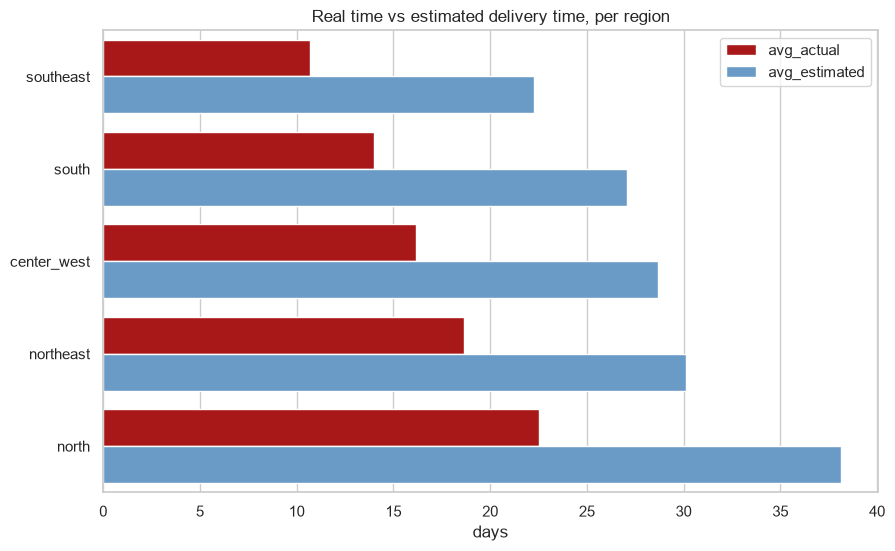

In [124]:
# gráfico barras tempo real vs tempo estimado por região
df_melt = geo_summary_region.melt(
    id_vars='customer_region',
    value_vars=['avg_actual', 'avg_estimated'],
    var_name='tipo',
    value_name='dias'
)

sns.barplot(
    data=df_melt,
    x='dias',
    y='customer_region',
    hue='tipo',
    order=region_order,
    palette={'avg_actual': '#C00000', 'avg_estimated': '#5B9BD5'},
)
plt.title('Real time vs estimated delivery time, per region')
plt.xlabel('days')
plt.ylabel('')
plt.legend(title='')
plt.show()

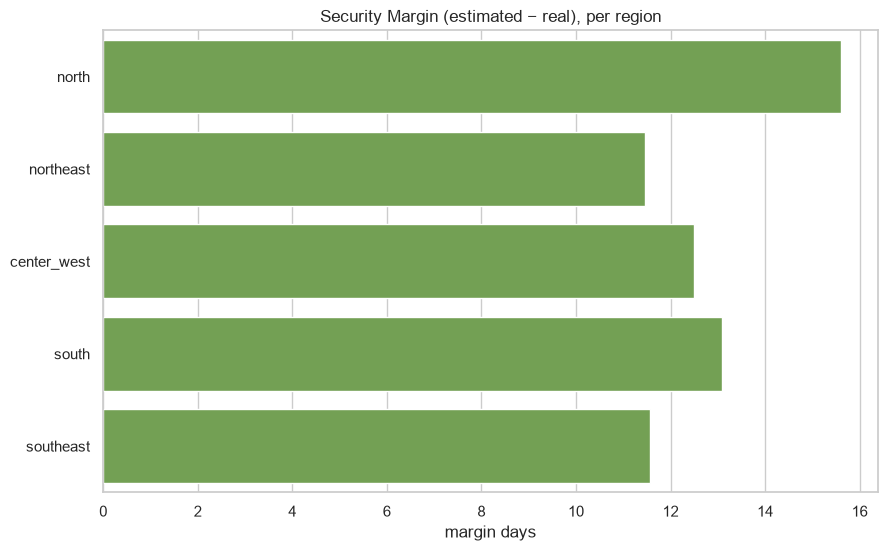

In [125]:
# gráfico barras de margem de segurança por região
sns.barplot(
    data=geo_summary_region,
    x='safety_margin',
    y='customer_region',
    color='#70AD47'
)
plt.title('Security Margin (estimated − real), per region')
plt.xlabel('margin days')
plt.ylabel('')
plt.show()

No primeiro gráfico, a distância entre a barra vermelha (tempo real) e a azul (tempo estimado) representa a margem de segurança de cada região — e essa distância cresce visivelmente de `southeast` para `north`.

No gráfico da direita, a margem aparece isolada e ordenada pelo mesmo critério (tempo real crescente). Aqui o padrão deixa de ser uma escada suave: `northeast` e `southeast` têm margens praticamente idênticas (~11.5 dias), apesar de `northeast` demorar 75% mais tempo a entregar (18.63 vs 10.69 dias). A escada só se torna visível a partir de `center_west`.

### Testes Estatísticos

#### Kruskal-Wallis

`actual_delivery_days` é uma variável contínua, mas com distribuição assimétrica à direita (como vimos na EDA de `delta_days`). O teste adequado para comparar a distribuição de uma variável contínua entre três ou mais grupos independentes, sem assumir normalidade, é o **Kruskal-Wallis**.

O objectivo é confirmar se a diferença de tempo de entrega observada entre regiões (10.69 dias no Sudeste vs 22.54 dias no Norte) é estatisticamente significativa, ou se pode ser explicada por variação aleatória dentro de cada grupo.

**H₀ (nula):** a distribuição de `actual_delivery_days` é igual entre todas as regiões 

**H₁ (alternativa):** pelo menos uma região tem distribuição de `actual_delivery_days` diferente das restantes

Nível de significância: α = 0.05

Se o Kruskal-Wallis rejeitar H₀, o passo seguinte é Mann-Whitney par a par nos pares mais relevantes (`southeast` vs `north`, `northeast` vs `southeast`, dado o achado da margem desigual) com correcção de Bonferroni.

In [126]:
# regiões isoladas em variável
regions = geo_summary_region['customer_region'].unique()

In [127]:
# criação laço for para criação de arrays de dias de entrega dentro de cada região
groups_region = []

for r in regions:
    group = q3[q3['customer_region'] == r]['actual_delivery_days'].values
    groups_region.append(group)

In [128]:
# aplicação teste estatístico Kruskal
stat, p_value = st.kruskal(*groups_region)
print(f"Kruskal-Wallis — actual_delivery_days por região: H={stat:.4f}, p={p_value:.4f}")

Kruskal-Wallis — actual_delivery_days por região: H=14238.4210, p=0.0000


**Kruskal-Wallis — teste global**

| teste | H | p-value | rejeita H₀? |
|---|---|---|---|
| `actual_delivery_days` entre as 5 regiões | 14238.42 | <0.0001 | ✓ Sim |

A diferença de tempo de entrega entre regiões é estatisticamente muito significativa. [Nota: com 96.461 observações, mesmo diferenças pequenas tendem a ser estatisticamente significativas — o H elevado reflecte em parte o volume de dados, e deve ser lido em conjunto com a magnitude prática observada nas médias (10.69 a 22.54 dias), não isoladamente.

#### Mann-Whitney

In [129]:
# separação regiões alvo
pares_region = [
    ('southeast', 'north'),
    ('northeast', 'southeast'),
    ('northeast', 'north')
]

In [130]:
results_region = []

# aplicação teste mann whitney 
for reg1, reg2 in pares_region:
    g1 = q3[q3['customer_region'] == reg1]['actual_delivery_days'].values
    g2 = q3[q3['customer_region'] == reg2]['actual_delivery_days'].values
    stat, p_value = st.mannwhitneyu(g1, g2, alternative='two-sided')
    results_region.append({
        'region1': reg1,
        'region2': reg2,
        'U': round(stat, 2),
        'p_value': round(p_value, 4),
        'significative': p_value < 0.05
    })

results_region = pd.DataFrame(results_region)

In [131]:
results_region['p_bonferroni'] = results_region['p_value'] * 3
results_region['significative_bonferroni'] = results_region['p_bonferroni'] < 0.05

print(results_region.to_string())

     region1    region2            U  p_value  significative  p_bonferroni  significative_bonferroni
0  southeast      north  17402197.00     0.00           True          0.00                      True
1  northeast  southeast 571252982.00     0.00           True          0.00                      True
2  northeast      north   7593878.50     0.00           True          0.00                      True


**Mann-Whitney par a par — com correcção de Bonferroni**

| par | U | p-value | p (Bonferroni) | significativo |
|---|---|---|---|---|
| southeast vs north | 17.402.197 | <0.0001 | <0.0001 | ✓ Sim |
| northeast vs southeast | 571.252.982 | <0.0001 | <0.0001 | ✓ Sim |
| northeast vs north | 7.593.878,5 | <0.0001 | <0.0001 | ✓ Sim |

Todos os pares testados mantêm significância estatística após correcção de Bonferroni. Em particular, a diferença entre `northeast` e `southeast` — que sustenta a observação sobre a calibração desigual da margem de segurança — está estatisticamente confirmada: não é um artefacto da agregação por região, mas um padrão real nos dados ao nível do pedido.

> **Síntese estatística:** A variação no tempo de entrega entre regiões é estatisticamente robusta em todos os pares testados, incluindo o par `northeast` vs `southeast` — confirmando que a calibração desigual da margem de segurança identificada anteriormente não resulta de ruído de amostra, mas de um padrão consistente nos dados.

### Conclusão

**Resposta à Pergunta 3:** 

Os atrasos têm origem predominantemente logística, não na promessa de prazo — mas a gestão dessa promessa não é uniforme. A Olist parece calibrar bem a margem de segurança onde a logística é mais extrema (`north`), mas falha em fazê-lo de forma proporcional no `northeast`, que acumula tempo de entrega elevado e margem de protecção insuficiente face a esse tempo. Isto torna o `northeast` — e não apenas o `north`, como a intuição inicial sugeriria — a região prioritária para intervenção, seja por optimização logística, seja por recalibração da janela de entrega prometida ao cliente.

## **Q4 - O Vendedor como Variável Oculta**  

Dentro do mesmo corredor logístico, há variância significativa de desempenho entre vendedores? Se sim, o problema não é a transportadora nem a distância — é o processo interno do vendedor.

### Distribuição de volume por vendedor-corredor

In [132]:
# criação variável corredor logístico
q3['corridor'] = q3['seller_state'] + '_' + q3['customer_state']

In [133]:
# criação agregado de volume de vendas de vendedores por corredor logístico
seller_volume = (
    q3.groupby(['corridor', 'seller_id'])
    .size()
    .reset_index(name='n_orders')
)

seller_volume

,corridor,seller_id,n_orders
0,AM_AL,327b89b872c14d1c0be7235ef4871685,1
1,AM_MA,327b89b872c14d1c0be7235ef4871685,1
2,AM_MG,327b89b872c14d1c0be7235ef4871685,1
3,BA_AC,53243585a1d6dc2643021fd1853d8905,1
4,BA_AL,53243585a1d6dc2643021fd1853d8905,5
...,...,...,...
17017,SP_TO,fa1c13f2614d7b5c4749cbc52fecda94,2
17018,SP_TO,fd386aa7bed2af3c7035c65506c9b4a3,1
17019,SP_TO,fe2032dab1a61af8794248c8196565c9,2
17020,SP_TO,ff063b022a9a0aab91bad2c9088760b7,1


In [134]:
# descoberta características do número de vendas por corredor entre vendedores
print(seller_volume['n_orders'].describe())

count   17022.00
mean        5.67
std        20.87
min         1.00
25%         1.00
50%         2.00
75%         4.00
max       795.00
Name: n_orders, dtype: float64


In [135]:
# descoberta rank quantia de vendedores por número de pedidos entre corredores 
print(seller_volume['n_orders'].value_counts().sort_index().head(20))

n_orders
1     8243
2     2791
3     1414
4      915
5      572
6      450
7      338
8      236
9      199
10     183
11     168
12     124
13     104
14      89
15      74
16      84
17      63
18      58
19      48
20      56
Name: count, dtype: int64


Confirma a hipótese de marketplace fragmentado: 8.243 dos 17.022 pares vendedor-corredor (48%) têm apenas 1 pedido. Acumulando: vendedor-corredores com ≤2 pedidos são 11.034 (65%), ≤3 são 12.448 (73%). 

A mediana é 2 pedidos — ou seja, mais de metade das combinações vendedor-corredor não tem volume suficiente para cálculos.

Isto muda a abordagem: em vez de filtrar vendedores com poucos pedidos por corredor (que eliminaria quase tudo), faz mais sentido inverter a pergunta — olhar para o volume total do vendedor (somado por todos os corredores), e dentro disso, focar nos corredores onde existe de facto concorrência entre múltiplos vendedores de volume suficiente. 

Sem isso, a "variância entre vendedores no mesmo corredor" não tem amostra para ser calculada na esmagadora maioria dos casos.

### Investigação corredores com volume e vendedores suficiente

#### Quantos corredores têm pelo menos 2 vendedores com volume razoável?

In [136]:
# vendedores com pelo menos N pedidos num corredor
N = 5

In [137]:
# quantos corredores têm pelo menos 2 vendedores com volume razoável
corridor_seller_filtered = (
    seller_volume[
        seller_volume['n_orders'] >= N
    ]
)

In [138]:
# corredores com pelo menos 2 vendedores distintos acima do threshold
corridors_with_competition = (
    corridor_seller_filtered.groupby('corridor')['seller_id']
    .nunique()
    .reset_index(name='n_sellers')
)

In [139]:
# descoberta número de vendedores por corredor
print(corridors_with_competition['n_sellers'].value_counts())

n_sellers
1      79
2      13
3      13
5       8
6       6
8       5
4       4
14      3
10      2
45      2
39      2
30      2
18      2
7       2
16      2
25      2
9       2
112     2
21      1
66      1
20      1
64      1
96      1
52      1
118     1
23      1
13      1
44      1
11      1
28      1
19      1
22      1
43      1
72      1
68      1
71      1
24      1
313     1
26      1
15      1
49      1
146     1
337     1
12      1
174     1
772     1
Name: count, dtype: int64


In [140]:
print(f"Corredores com 2+ vendedores (N>={N}): {(corridors_with_competition['n_sellers'] >= 2).sum()}")

Corredores com 2+ vendedores (N>=5): 100


Com N≥5, há 100 corredores com pelo menos 2 vendedores em condições de ser comparados, e a cauda chega a um corredor com 772 pedidos de um único vendedor de volume muito alto (provavelmente SP→SP).

#### Volume total do vendedor (todos os corredores somados), não só por corredor


In [141]:
# volume total do vendedor todos os corredores somados
seller_total_volume = q3.groupby('seller_id').size().reset_index(name='total_orders')
print(seller_total_volume['total_orders'].describe())

count   2960.00
mean      32.59
std      104.38
min        1.00
25%        2.00
50%        7.00
75%       22.00
max     1809.00
Name: total_orders, dtype: float64


Distribuição também muito assimétrica — mediana de apenas 7 pedidos totais por vendedor, mas com um vendedor a chegar a 1.809 pedidos. Isto é consistente com a estrutura típica de marketplaces: uma cauda longa de poucos vendedores de grande volume e uma massa de vendedores pequenos/ocasionais.

#### **Conclusão**

Com os dois resultados em mãos:

* N≥5 por corredor já filtra naturalmente para vendedores com alguma actividade recorrente nesse trajecto específico
* 100 corredores com 2+ vendedores comparáveis é uma base sólida — nem tão restrita que fique sem dados, nem tão ampla que inclua comparações de 1 pedido vs 1 pedido

Usar N≥5 por corredor como filtro principal (já validado), sem necessidade de um filtro adicional de volume total do vendedor — porque o filtro por corredor já garante que qualquer vendedor incluído na análise tem pelo menos 5 pedidos no corredor específico que está a ser comparado, independentemente do seu volume total nos outros corredores.

### Aplicação filtro

In [142]:
# filtro apenas vendedor-corredor com N >= 5
valid_pairs = seller_volume[seller_volume['n_orders'] >= 5][['corridor', 'seller_id']]

In [143]:
# filtro: apenas corredores com 2+ vendedores válidos
valid_corridors = corridors_with_competition[
    corridors_with_competition['n_sellers'] >= 2
]['corridor']

valid_pairs = valid_pairs[valid_pairs['corridor'].isin(valid_corridors)]

# descobertas
print(f"Pares vendedor-corredor válidos: {len(valid_pairs)}")
print(f"Corredores únicos: {valid_pairs['corridor'].nunique()}")
print(f"Vendedores únicos: {valid_pairs['seller_id'].nunique()}")

Pares vendedor-corredor válidos: 3580
Corredores únicos: 100
Vendedores únicos: 1181


In [144]:
# juntar q3 com os pares válidos para filtrar só os pedidos relevantes para a análise
q4 = q3.merge(valid_pairs, on=['corridor', 'seller_id'], how='inner')
print(f"Pedidos na análise Q4: {len(q4)}")

Pedidos na análise Q4: 73770


Números coerentes e bem dimensionados: 3.580 pares vendedor-corredor, 100 corredores, 1.181 vendedores distintos — base suficiente para uma análise de variância robusta.

### Agregação vendedor-corredor (pós filtro)

In [145]:
# agregação por vendedor e corredor
seller_performance = (
    q4.groupby(['corridor', 'seller_id'])
    .agg(
        n_orders=('order_id', 'count'),
        avg_delta=('delta_days', 'mean'),
        std_delta=('delta_days', 'std'),
        avg_actual=('actual_delivery_days', 'mean'),
        std_actual=('actual_delivery_days', 'std'),
        pct_late=('delta_days', lambda x: (x > 0).sum() / len(x))
    )
    .reset_index()
)

print(seller_performance.shape)
print(seller_performance.head(10).to_string())

(3580, 8)
  corridor                         seller_id  n_orders  avg_delta  std_delta  avg_actual  std_actual  pct_late
0    BA_BA  53243585a1d6dc2643021fd1853d8905        43     -10.58       6.58        8.93        3.98      0.02
1    BA_BA  75d34ebb1bd0bd7dde40dd507b8169c3         8      -1.00      15.07       22.12       10.89      0.38
2    BA_MG  53243585a1d6dc2643021fd1853d8905        35     -14.46       4.57       10.63        3.46      0.00
3    BA_MG  75d34ebb1bd0bd7dde40dd507b8169c3         7     -24.43       6.32       11.57        2.76      0.00
4    BA_RJ  4aba391bc3b88717ce08eb11e44937b2        10     -12.30      19.77       19.80       16.61      0.20
5    BA_RJ  53243585a1d6dc2643021fd1853d8905        50     -11.74       6.59       12.54        4.56      0.00
6    BA_RJ  75d34ebb1bd0bd7dde40dd507b8169c3         7     -22.71      12.32       12.86        6.20      0.14
7    BA_RJ  a3dd39f583bc80bd8c5901c95878921e         5     -11.00       5.61       11.80        4.38  

Três métricas principais por vendedor-corredor:

* avg_delta / avg_actual — desempenho médio (velocidade)
* std_delta / std_actual — consistência (variância dentro do vendedor)
* pct_late — proporção de pedidos entregues com atraso

Mesmo corredor (Bahia → Bahia), dois vendedores com desempenhos radicalmente diferentes: o primeiro entrega em ~9 dias com baixíssima variância e 2% de atraso; o segundo demora 22 dias em média, com altíssima variância (std=15) e 38% de atraso. 

In [146]:
# variância entre vendedores dentro do mesmo corredor
corridor_variance = (
    seller_performance.groupby('corridor')
    .agg(
        n_sellers=('seller_id', 'count'),
        n_orders_total=('n_orders', 'sum'),
        avg_delta_corridor=('avg_delta', 'mean'),
        std_delta_between=('avg_delta', 'std'),
        avg_pct_late=('pct_late', 'mean'),
        std_pct_late=('pct_late', 'std')
    )
    .reset_index()
    .sort_values('std_delta_between', ascending=False)
)

print(corridor_variance.head(20).to_string())

   corridor  n_sellers  n_orders_total  avg_delta_corridor  std_delta_between  avg_pct_late  std_pct_late
21    MG_ES          8              85              -17.68              13.15          0.03          0.07
33    MS_SP          2              14              -21.44               9.81          0.08          0.12
4     CE_SP          3              16              -18.90               9.66          0.00          0.00
18    MG_BA         21             212              -10.13               9.43          0.09          0.11
51    RJ_CE          3              20               -9.64               8.93          0.22          0.15
56    RJ_PA          3              18              -14.64               7.34          0.05          0.08
13    ES_RJ          2              43               -6.66               7.29          0.12          0.06
50    RJ_BA          5              71               -9.93               7.25          0.11          0.14
7     DF_MG          6              75        

`std_delta_between` mede o quão diferentes são os vendedores do mesmo corredor entre si — corredores com valor alto são os mais interessantes para a narrativa da Pergunta 4, porque é onde o vendedor mais "faz a diferença".

Corredores de alto volume com alta variância: 

* MG_RJ: 64 vendedores, 998 pedidos, `std_delta_between`= 6.95 — o corredor com mais volume e variância significativa entre vendedores
* SP_MA: 24 vendedores, 215 pedidos, `std_delta_between`= 5.82
* MG_BA: 21 vendedores, 212 pedidos, `std_delta_between`= 9.43
* SP_PI: 9 vendedores, 73 pedidos, `std_delta_between`= 6.37

Corredores de baixo volume com alta variância (interessantes mas com cautela):

* MG_ES: 8 vendedores, 85 pedidos, `std_delta_between` = 13.15 — maior variância mas volume mais modesto
* MS_SP: apenas 2 vendedores, 14 pedidos — variância calculada sobre amostra muito pequena, não fiável

Os corredores MG_RJ e MG_BA são os mais defensáveis: alto volume, múltiplos vendedores, variância real e não apenas ruído de amostra pequena.

In [147]:
# filtro para corredores com maior robustez de dados
mgrj = seller_performance[seller_performance['corridor'] == 'MG_RJ'].sort_values('avg_delta')

print(f"Vendedores no corredor MG_RJ: {len(mgrj)}")
print()
print(mgrj[['seller_id', 'n_orders', 'avg_delta', 'std_delta', 'avg_actual', 'pct_late']].to_string())

Vendedores no corredor MG_RJ: 64

                            seller_id  n_orders  avg_delta  std_delta  avg_actual  pct_late
273  b92e3c8f9738272ff7c59e111e108d7c        10     -43.10      22.89       14.70      0.00
262  8444e55c1f13cd5c179851e5ca5ebd00        15     -28.67      12.31       20.87      0.00
276  cc5a78bbad32776dc4e3af205218368c         6     -28.33       7.09        7.67      0.00
241  2a5b78b41cd05baeac8df54c6606b92c         6     -25.50      14.18        9.83      0.00
250  58f1a6197ed863543e0136bdedb3fce2         7     -22.57       8.02        9.00      0.00
266  93dc87703c046b603023e75222018b45         5     -21.40      14.26       16.20      0.00
278  cfa5ab0e4d3fc212fd0b3410e7081c62         5     -21.40       9.89       10.20      0.00
246  49067458c68f7701fd334ce326accbe0         5     -20.40      16.04        9.80      0.00
253  5bc24d989e71e93c33e50a7782431b0e         5     -20.00       5.92        7.60      0.00
284  dd2bdf855a9172734fbc3744021ae9b9        1

O corredor MG_RJ — 64 vendedores, amplitude de avg_delta de -43 a +5 dias, e casos extremos com volume suficiente para sustentar a comparação. 

Mesmo corredor (MG→RJ), volume comparável (~10-11 pedidos), resultados opostos. O terceiro vendedor não só atrasa em média (+5 dias), como tem a maior variância de toda a lista (std=38.53) — extremamente inconsistente. 

O segundo é o oposto: rápido, consistente, zero atrasos, menor avg_actual de todo o corredor (7 dias).

### Visualizações diferenças entre vendedores por corredor

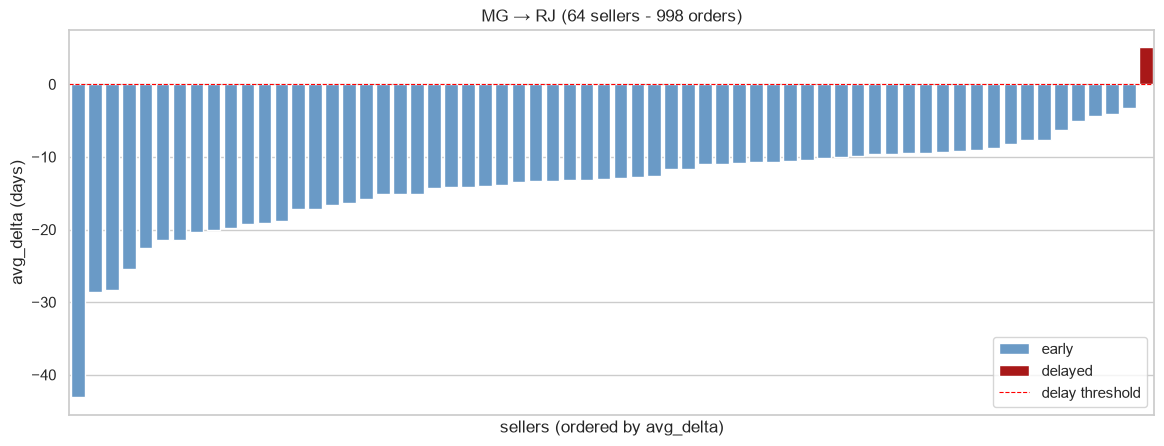

In [148]:
# gráfico barras corredor MG → RJ
df_corridor = seller_performance[seller_performance['corridor'] == 'MG_RJ'].sort_values('avg_delta').reset_index(drop=True)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=df_corridor,
    x=df_corridor.index,
    y='avg_delta',
    hue=df_corridor['avg_delta'].apply(lambda x: 'delayed' if x > 0 else 'early'),
    palette={'early': '#5B9BD5', 'delayed': '#C00000'},
    legend=True
)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, label='delay threshold')
plt.title('MG → RJ (64 sellers - 998 orders)')
plt.xlabel('sellers (ordered by avg_delta)')
plt.ylabel('avg_delta (days)')
plt.xticks([])
plt.legend()
plt.show()

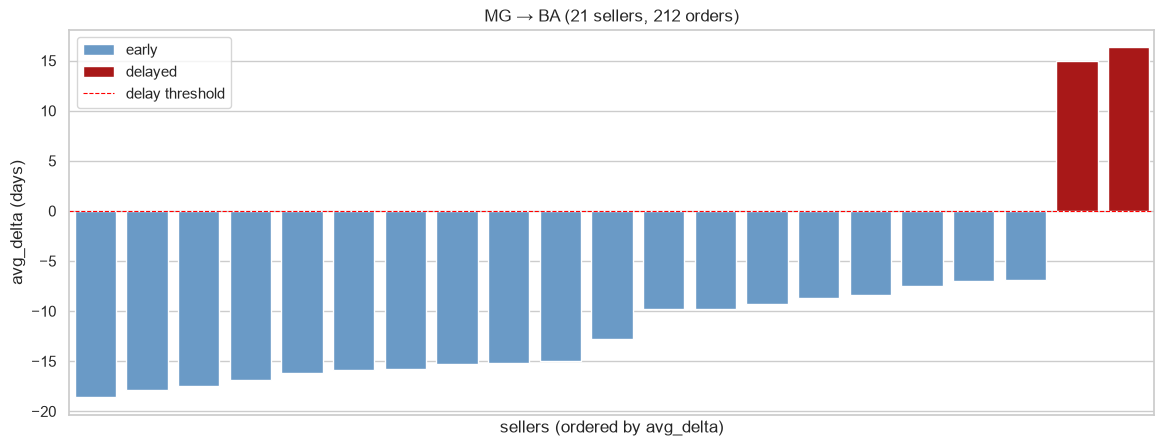

In [149]:
# corredor MG → BA
df_corridor = seller_performance[seller_performance['corridor'] == 'MG_BA'].sort_values('avg_delta').reset_index(drop=True)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=df_corridor,
    x=df_corridor.index,
    y='avg_delta',
    hue=df_corridor['avg_delta'].apply(lambda x: 'delayed' if x > 0 else 'early'),
    palette={'early': '#5B9BD5', 'delayed': '#C00000'},
    legend=True
)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, label='delay threshold')
plt.title('MG → BA (21 sellers, 212 orders)')
plt.xlabel('sellers (ordered by avg_delta)')
plt.ylabel('avg_delta (days)')
plt.xticks([])
plt.legend()
plt.show()

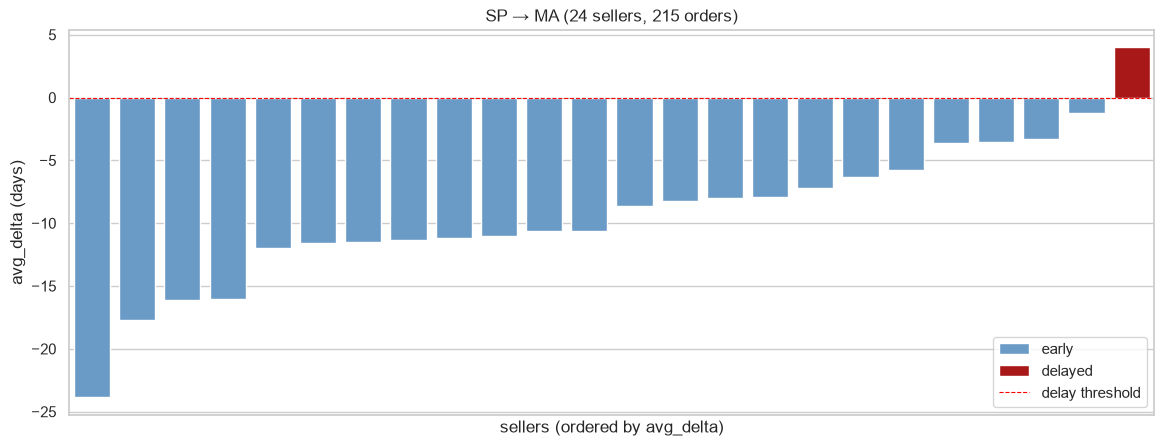

In [150]:
# corredor SP → MA
df_corridor = seller_performance[seller_performance['corridor'] == 'SP_MA'].sort_values('avg_delta').reset_index(drop=True)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=df_corridor,
    x=df_corridor.index,
    y='avg_delta',
    hue=df_corridor['avg_delta'].apply(lambda x: 'delayed' if x > 0 else 'early'),
    palette={'early': '#5B9BD5', 'delayed': '#C00000'},
    legend=True
)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, label='delay threshold')
plt.title('SP → MA (24 sellers, 215 orders)')
plt.xlabel('sellers (ordered by avg_delta)')
plt.ylabel('avg_delta (days)')
plt.xticks([])
plt.legend()
plt.show()

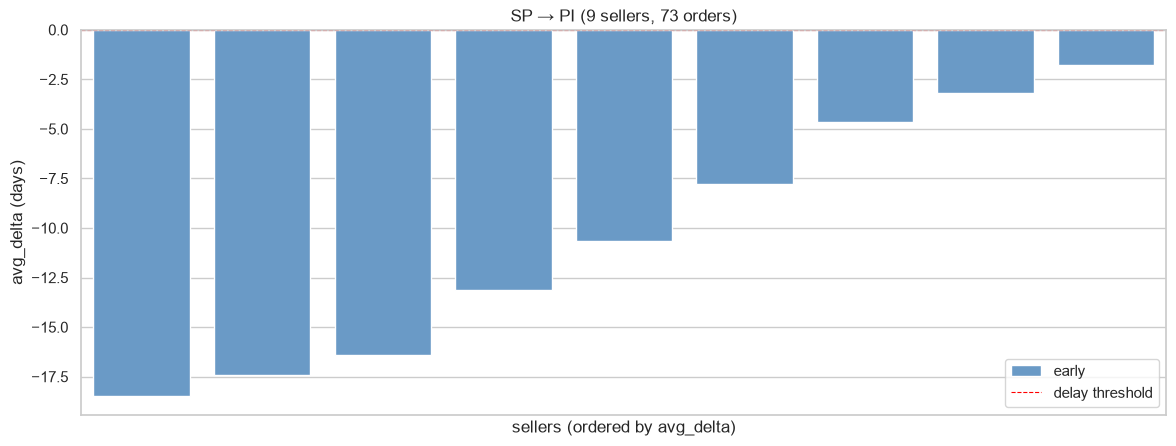

In [151]:
# corredor SP → PI
df_corridor = seller_performance[seller_performance['corridor'] == 'SP_PI'].sort_values('avg_delta').reset_index(drop=True)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=df_corridor,
    x=df_corridor.index,
    y='avg_delta',
    hue=df_corridor['avg_delta'].apply(lambda x: 'delayed' if x > 0 else 'early'),
    palette={'early': '#5B9BD5', 'delayed': '#C00000'},
    legend=True
)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, label='delay threshold')
plt.title('SP → PI (9 sellers, 73 orders)')
plt.xlabel('sellers (ordered by avg_delta)')
plt.ylabel('avg_delta (days)')
plt.xticks([])
plt.legend()
plt.show()

Os quatro gráficos mostram, para cada corredor seleccionado, o `avg_delta` médio de cada vendedor ordenado do melhor (mais negativo = mais antecipado) para o pior (mais positivo = mais atrasado). A linha tracejada vermelha marca o limiar de atraso (`delta_days = 0`).

**`MG → RJ`** (64 vendedores, 998 pedidos): o corredor com mais volume e maior amplitude (48 dias entre o melhor e o pior vendedor). A curva em "rampa suave" revela uma distribuição contínua de desempenho — não há um grupo claramente separado de vendedores maus, mas sim uma degradação gradual. Apenas 2 vendedores ultrapassam o limiar de atraso.

**`MG → BA`** (21 vendedores, 212 pedidos): amplitude de 35 dias, com 2 vendedores a acumular atrasos médios de +14 e +16 dias — os casos mais extremos de atraso médio dos quatro corredores.

**`SP → MA`** (24 vendedores, 215 pedidos): padrão semelhante ao `MG_BA`, com 1 vendedor a ultrapassar o limiar com +4 dias de atraso médio e amplitude de 28 dias.

**`SP → PI`** (9 vendedores, 73 pedidos): único corredor onde todos os vendedores entregam antes do prazo — mas a amplitude de 16 dias mostra que mesmo sem atrasos, há vendedores sistematicamente mais lentos do que os seus pares no mesmo corredor.

> Em todos os casos, a variância observada não pode ser atribuída à distância (é a mesma para todos os vendedores do corredor) nem à transportadora (os melhores e piores coexistem nas mesmas rotas). O que separa os extremos é o processo interno do vendedor: tempo até despacho, qualidade da embalagem, e parceiro logístico escolhido.

### Testes estatísticos — Variância entre vendedores por corredor

#### Contexto

O objectivo é confirmar se as diferenças de `avg_delta` observadas entre vendedores no mesmo corredor são estatisticamente significativas, ou se podem ser explicadas por variação aleatória dentro de cada grupo.

Usa-se o **Kruskal-Wallis** — adequado para comparar distribuições entre três ou mais grupos independentes sem assumir normalidade — aplicado ao corredor `MG_RJ` (o mais robusto: 64 vendedores, 998 pedidos). Se o teste global rejeitar H₀, aplica-se Mann-Whitney par a par nos pares extremos (melhor vs pior vendedor) com correcção de Bonferroni.

**H₀ (nula):** a distribuição de `delta_days` é igual entre todos os vendedores do corredor `MG_RJ`

**H₁ (alternativa):** pelo menos um vendedor tem distribuição de `delta_days` diferente dos restantes

Nível de significância: α = 0.05

#### Kruskal-Wallis

In [152]:
# filtro pedidos do corredor MG_RJ
mgrj_orders = q4[q4['corridor'] == 'MG_RJ']

In [153]:
# grupos: um array de delta_days por vendedor
sellers_mgrj = mgrj_orders['seller_id'].unique()

In [154]:
# laço for para 
groups_mgrj = []

for s in sellers_mgrj:
    group = mgrj_orders[mgrj_orders['seller_id'] == s]['delta_days'].values
    groups_mgrj.append(group)

In [155]:
# aplicação Kruskal-Wallis
stat, p_value = st.kruskal(*groups_mgrj)
print(f"Kruskal-Wallis — delta_days entre vendedores MG_RJ: H={stat:.4f}, p={p_value:.4f}")

Kruskal-Wallis — delta_days entre vendedores MG_RJ: H=163.2584, p=0.0000


p≈0 confirma que a variância entre vendedores no corredor MG_RJ é estatisticamente significativa.

#### Mann-Whitney

In [156]:
# identificação dos vendedores extremos no corredor MG_RJ
better = mgrj[mgrj['avg_delta'] == mgrj['avg_delta'].min()]['seller_id'].values[0]
worse = mgrj[mgrj['avg_delta'] == mgrj['avg_delta'].max()]['seller_id'].values[0]

print(f"Melhor vendedor: {better} (avg_delta={mgrj['avg_delta'].min():.2f})")
print(f"Pior vendedor:   {worse} (avg_delta={mgrj['avg_delta'].max():.2f})")

Melhor vendedor: b92e3c8f9738272ff7c59e111e108d7c (avg_delta=-43.10)
Pior vendedor:   7ea5bfa6c340f58f8e71fc1f0412b0d6 (avg_delta=5.09)


In [157]:
# arrays de delta_days por vendedor
g_better = mgrj_orders[mgrj_orders['seller_id'] == better]['delta_days'].values
g_worse = mgrj_orders[mgrj_orders['seller_id'] == worse]['delta_days'].values

print(f"\nPedidos melhor vendedor: {len(g_better)}")
print(f"Pedidos pior vendedor:   {len(g_worse)}")


Pedidos melhor vendedor: 10
Pedidos pior vendedor:   11


In [158]:
# Mann-Whitney
stat, p_value = st.mannwhitneyu(g_better, g_worse, alternative='two-sided')

print(f"\nMann-Whitney U={stat:.2f}, p={p_value:.4f}")
print(f"Significativo (α=0.05): {p_value < 0.05}")


Mann-Whitney U=11.00, p=0.0022
Significativo (α=0.05): True


Resultado limpo e conclusivo. O par mais extremo do corredor MG_RJ é estatisticamente significativo (p=0.0022)

#### Resultados dos testes

**Kruskal-Wallis — teste global**

| teste | H | p-value | rejeita H₀? |
|---|---|---|---|
| `delta_days` entre 64 vendedores no corredor `MG_RJ` | 163.26 | <0.0001 | ✓ Sim |

A variância de desempenho entre vendedores no corredor `MG_RJ` é estatisticamente muito significativa. Pelo menos um vendedor tem distribuição de `delta_days` claramente diferente dos restantes.

**Mann-Whitney — par extremo (melhor vs pior vendedor)**

| par | n pedidos | p-value | significativo |
|---|---|---|---|
| melhor (`avg_delta` = −43.10) vs pior (`avg_delta` = +5.09) | 10 vs 11 | 0.0022 | ✓ Sim |

A diferença entre o melhor e o pior vendedor do corredor é estatisticamente robusta mesmo com volumes reduzidos (10 e 11 pedidos) — o que reforça a magnitude real da diferença: uma amplitude de 48 dias de `avg_delta` entre dois vendedores que operam na mesma rota, com a mesma distância e presumivelmente as mesmas transportadoras disponíveis.

### Conclusão

**Resposta à Pergunta 4:** dentro do mesmo corredor logístico, existe variância significativa de desempenho entre vendedores — estatisticamente confirmada (Kruskal-Wallis H=163.26, p<0.0001 no corredor `MG_RJ`). A amplitude de 48 dias de `avg_delta` entre o melhor e o pior vendedor do mesmo corredor não pode ser atribuída à distância nem à transportadora — é idêntica para todos. O que separa os extremos é o processo interno do vendedor.

> O problema não está sempre onde parece. Quando um cliente recebe um pedido atrasado no corredor MG→RJ, o reflexo natural é culpar a distância ou a transportadora. Os dados mostram que, nesse mesmo corredor, há vendedores que entregam consistentemente 43 dias antes do prazo — e outros que acumulam atrasos médios de 5 dias. 
>
> A rota é a mesma. A diferença está no vendedor.

# **Conclusão geral**

As quatro análises foram construídas em camadas de profundidade crescente, partindo de uma variável simples (`delta_days`) e chegando ao vendedor individual como unidade de responsabilidade:

## Análise 1 — O atraso não é simétrico

O impacto do atraso na avaliação varia por contexto — mas a janela de diferenciação é estreita: apenas nos primeiros 5 dias. Acima de 6 dias, todas as categorias colapsam para o mesmo nível de insatisfação (review médio ~1.6–1.8, ~70% de nota 1). 

O valor do pedido amplifica esse colapso: o tier `premium` (>R$1.048) atinge 87% de nota 1 no `late_critical` — o resultado mais extremo de toda a análise.

## Análise 2 — Existe um limiar, não uma degradação linear

A relação entre atraso e insatisfação não é gradual — é um threshold. Até 5 dias de atraso, o cliente ainda diferencia e a nota deteriora progressivamente. 

A partir do dia 6, a nota colapsa abruptamente para ~1.8 e estabiliza indefinidamente. Uma transportadora que reduz o atraso de 8 para 6 dias não resolve o problema — reduzir de 6 para 5 dias pode fazer toda a diferença.

## Análise 3 — O problema logístico é estrutural, não de expectativa

Nenhuma região atrasa em média — a Olist calibra prazos proporcionalmente à realidade logística de cada área. O problema real é o tempo de entrega absoluto: o Norte demora mais do dobro que o Sudeste (22.54 vs 10.69 dias). 

O `northeast` acumula uma desvantagem dupla: tempo de entrega elevado e margem de segurança desproporcionalmente apertada face a esse tempo — tornando-o a região prioritária para intervenção, à frente do `north`.

## Análise 4 — O vendedor é a variável oculta

Dentro do mesmo corredor logístico, há vendedores que entregam 43 dias antes do prazo e vendedores que acumulam atrasos médios de 5 dias. A diferença é estatisticamente robusta e não pode ser explicada por factores externos. 

O vendedor — o seu processo de despacho, o seu parceiro logístico, a sua operação interna — é a variável que mais pode ser accionada para reduzir atrasos sem depender de infraestrutura ou política regional.

## **Conclusão global:**

>
> O custo oculto do atraso não está distribuído uniformemente. Concentra-se num limiar específico (dia 6), em categorias e valores específicos (toys, premium), numa região com > calibração inadequada (northeast), e — acima de tudo — em vendedores > específicos que operam abaixo do padrão dos seus pares no mesmo
> corredor. 
>
> Identificar esses vendedores e actuar sobre os seus > processos internos é a alavanca operacional com maior retorno > potencial neste dataset.

## Exportação

In [159]:
# exportação dados para csv
q1.to_csv('../data/processed/q1_satisfaction.csv', index=False)

In [160]:
# exportação dados para csv
q3.to_csv('../data/processed/q3_logistic.csv', index=False)

In [161]:
# exportação dados para csv
seller_performance.to_csv('../data/processed/seller_performance.csv', index=False)